# Greedy Adversarial Training for IoT Device Identification

This notebook trains 6 models on CSV + JSON datasets with a **3-phase greedy adversarial curriculum**:

| Phase | Epochs | Adversarial Ratio | k_max | Purpose |
|-------|--------|-------------------|-------|---------|
| A | 1-15 | 0% | 0 | Learn the base task on clean data |
| B | 16-30 | 30% | 2 | Gentle introduction of greedy attacks |
| C | 31-50 | 70% | 4 | Full adversarial training against greedy search |

**GreedyAttackSimulator** reads `sensitivity_results.csv` and applies the exact same
perturbations (Zero, Mimic_Mean, Mimic_95th, Padding_x10) on the same vulnerable
features as the attacker. No TRADES or IBP needed — we train against the known attack.

**Models**: LSTM, BiLSTM, CNN-LSTM, XGBoost-LSTM, Transformer, CNN-BiLSTM-Transformer

Each phase saves/loads from **Google Drive** so training can be resumed without re-running.

# Phase 1 : Setup

In [1]:
import math
# ─── Cell: Setup ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
if os.path.exists('/content/pfe'):
    !cd /content/pfe && git pull
else:
    !git clone https://github.com/yacinemkk/pfe.git /content/pfe

%cd /content/pfe

!pip install -q torch torchvision tqdm numpy pandas scikit-learn matplotlib xgboost psutil


Mounted at /content/drive
Cloning into '/content/pfe'...
remote: Enumerating objects: 1415, done.
remote: Counting objects: 100% (245/245), done.
remote: Compressing objects: 100% (167/167), done.
remote: Total 1415 (delta 148), reused 157 (delta 78), pack-reused 1170 (from 1)
Receiving objects: 100% (1415/1415), 15.46 MiB | 16.05 MiB/s, done.
Resolving deltas: 100% (808/808), done.
/content/pfe


# Phase 2 : Configuration & Data Pipeline

In [2]:
# ─── Cell: Configuration ─────────────────────────────────────────────────
import os

JSON_DATA_DIR = '/content/drive/MyDrive/PFE/IPFIX_Records'
CSV_DATA_DIR = '/content/drive/MyDrive/PFE/IPFIX_ML_Instances'
DRIVE_RESULTS_DIR = '/content/drive/MyDrive/PFE/results'
DATASETS = 'both'

SEQ_LENGTH = 10
STRIDE = 10
BATCH_SIZE = 2048         # Augmenté pour accélérer l'entraînement (optimisé)
LEARNING_RATE = 5e-4
USE_AMP = True           # mixed-precision (fp16) — cuts VRAM ~50%

CSV_USE_BALANCED_PREPROCESSED = True
JSON_USE_BALANCED_PREPROCESSED = True
JSON_SMOTE_FORCE_REBUILD = False
JSON_SMOTE_CACHE_VERSION = 'v2-stronger-balance'
JSON_SMOTE_TARGET_QUANTILE = 0.65
JSON_SMOTE_MAX_MULTIPLIER = 128.0
JSON_SMOTE_MAX_NEW_SAMPLES = 500000
JSON_SMOTE_CONTEXT_MULTIPLIER = 1.25
JSON_SMOTE_K_NEIGHBORS = 5
JSON_SMOTE_RANDOM_STATE = 42
CSV_SMOTE_FORCE_REBUILD = False
CSV_SMOTE_CACHE_VERSION = 'v2-stronger-balance'
CSV_SMOTE_TARGET_QUANTILE = 0.65
CSV_SMOTE_MAX_MULTIPLIER = 128.0
CSV_SMOTE_MAX_NEW_SAMPLES = 500000
CSV_SMOTE_CONTEXT_MULTIPLIER = 1.25
CSV_SMOTE_K_NEIGHBORS = 5
CSV_SMOTE_RANDOM_STATE = 42

# Lighter CNN-BiLSTM-Transformer to fit within 22 GB VRAM
CNN_BILSTM_TRANSFORMER_OVERRIDE = {
    'cnn_channels': 32,          # was 64
    'bilstm_hidden': 64,         # was 128  → bilstm output = 128
    'bilstm_layers': 2,
    'bilstm_dropout': 0.3,
    'transformer_d_model': 128,  # was 256
    'transformer_nhead': 4,
    'transformer_layers': 2,
    'transformer_ff_dim': 512,   # reverted to 512
    'transformer_dropout': 0.2,
    'fc_dropout': 0.4,
}

# Greedy adversarial training phases
# ── Curriculum v3 : Threshold-Gated + Replay ──────────────────────────
MAX_PHASE_EPOCHS  = 20      # timeout par phase (même si seuil non atteint)
K_THRESHOLD       = 0.85    # cible de robustesse par phase
K_STABLE          = 0.82    # seuil de stabilité des k précédents
K_BACKSTEP        = 0.80    # déclenche retour D2→D1
K_RESUME_D2       = 0.83    # hysteresis : reprend D2 si k > 0.83
N_CONSEC_D2       = 3       # nb d'epochs consécutives à K_THRESHOLD pour arrêt D2

# Mix ratios par phase
PHASE_0_MIX_RATIO  = 0.0   # Bootstrap : 100% clean
PHASE_B1_MIX_RATIO = 0.4   # 60% clean / 40% adv
PHASE_B2_MIX_RATIO = 0.5   # 50% clean / 50% adv
PHASE_C_MIX_RATIO  = 0.7   # 30% clean / 70% adv
PHASE_D1_MIX_RATIO = 0.85  # 15% clean / 85% adv
PHASE_D2_MIX_RATIO = 0.95  # 5%  clean / 95% adv

PHASE_B_K_MAX = 2
PHASE_C_K_MAX = 4
PHASE_D_K_MAX = 4

GREEDY_STRATEGIES = ['Zero', 'Mimic_Mean', 'Mimic_95th', 'Padding_x10']

MAX_FILES = None
MAX_RECORDS = None
EVAL_SUBSAMPLE = 5000
EVAL_BATCH_SIZE = 256

os.makedirs(DRIVE_RESULTS_DIR, exist_ok=True)

print(f'CSV data:     {CSV_DATA_DIR}')
print(f'JSON data:    {JSON_DATA_DIR}')
print(f'Results dir:  {DRIVE_RESULTS_DIR}')
print(f'Datasets:     {DATASETS}')
print(f'Seq length:   {SEQ_LENGTH}')
print(f'Phase A: epochs 1-15   | mix=0%   | k_max=0 (clean only)')
print(f'Phase B: epochs 16-30  | mix=30%  | k_max=2')
print(f'Phase C: epochs 31-50 | mix=70%  | k_max=4')
print(f'Batch size:   {BATCH_SIZE}')
print(f'LR:           {LEARNING_RATE}')

import glob
csv_files = glob.glob(f'{CSV_DATA_DIR}/home*_labeled.csv')
print(f'\nFound {len(csv_files)} CSV file(s)')
for f in sorted(csv_files)[:5]:
    size_mb = os.path.getsize(f) / (1024**2)
    print(f'  {os.path.basename(f)} ({size_mb:.1f} MB)')
if len(csv_files) > 5:
    print(f'  ... and {len(csv_files) - 5} more')

json_files = glob.glob(f'{JSON_DATA_DIR}/**/*.json', recursive=True)
print(f'\nFound {len(json_files)} JSON file(s)')
for f in json_files:
    size_gb = os.path.getsize(f) / (1024**3)
    print(f'  {os.path.basename(f)} ({size_gb:.1f} GB)')


CSV data:     /content/drive/MyDrive/PFE/IPFIX_ML_Instances
JSON data:    /content/drive/MyDrive/PFE/IPFIX_Records
Results dir:  /content/drive/MyDrive/PFE/results
Datasets:     both
Seq length:   10
Phase A: epochs 1-15   | mix=0%   | k_max=0 (clean only)
Phase B: epochs 16-30  | mix=30%  | k_max=2
Phase C: epochs 31-50 | mix=70%  | k_max=4
Batch size:   2048
LR:           0.0005

Found 12 CSV file(s)
  home10_labeled.csv (1099.6 MB)
  home11_labeled.csv (215.8 MB)
  home12_labeled.csv (332.2 MB)
  home1_labeled.csv (245.0 MB)
  home2_labeled.csv (297.0 MB)
  ... and 7 more

Found 3 JSON file(s)
  ipfix_202003.json (5.7 GB)
  ipfix_202004.json (5.3 GB)
  ipfix_202001_fixed.json (6.6 GB)


In [3]:
# ─── Cell: RAM Monitoring & Data Loading ─────────────────────────────────
import gc
import os
import pickle
from collections import Counter

import numpy as np
import psutil
import torch


def get_memory_usage():
    process = psutil.Process(os.getpid())
    ram_gb = process.memory_info().rss / (1024**3)
    gpu_gb = 0
    if torch.cuda.is_available():
        gpu_gb = torch.cuda.memory_allocated() / (1024**3)
    return ram_gb, gpu_gb


def log_memory(label=''):
    ram_gb, gpu_gb = get_memory_usage()
    print(f'  [RAM {label}] {ram_gb:.2f} GB | [GPU {label}] {gpu_gb:.2f} GB')


def aggressive_cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    gc.collect()
    ram_gb, gpu_gb = get_memory_usage()
    print(f'  [Cleanup] RAM: {ram_gb:.2f} GB | GPU: {gpu_gb:.2f} GB')


def print_class_distribution(y, prefix=''):
    counts = Counter(np.asarray(y).ravel().tolist())
    total = sum(counts.values())
    for cls_id, count in sorted(counts.items(), key=lambda item: item[1], reverse=True):
        pct = 100.0 * count / max(total, 1)
        print(f'    {prefix}class={cls_id:<3d} count={count:>8,} ({pct:>5.2f}%)')
    return counts



def get_json_smote_config():
    return {
        'cache_version': JSON_SMOTE_CACHE_VERSION,
        'target_quantile': float(JSON_SMOTE_TARGET_QUANTILE),
        'max_multiplier': float(JSON_SMOTE_MAX_MULTIPLIER),
        'max_new_samples': int(JSON_SMOTE_MAX_NEW_SAMPLES),
        'context_multiplier': float(JSON_SMOTE_CONTEXT_MULTIPLIER),
        'k_neighbors': int(JSON_SMOTE_K_NEIGHBORS),
        'random_state': int(JSON_SMOTE_RANDOM_STATE),
    }

def get_csv_smote_config():
    return {
        'cache_version': CSV_SMOTE_CACHE_VERSION,
        'target_quantile': float(CSV_SMOTE_TARGET_QUANTILE),
        'max_multiplier': float(CSV_SMOTE_MAX_MULTIPLIER),
        'max_new_samples': int(CSV_SMOTE_MAX_NEW_SAMPLES),
        'context_multiplier': float(CSV_SMOTE_CONTEXT_MULTIPLIER),
        'k_neighbors': int(CSV_SMOTE_K_NEIGHBORS),
        'random_state': int(CSV_SMOTE_RANDOM_STATE),
    }


def _load_preprocessed_dataset(preprocessed_dir, dataset_type, expected_smote_config=None):
    ready_file = f'{preprocessed_dir}/{dataset_type}_ready'
    train_file = f'{preprocessed_dir}/X_train.npy'
    meta_file = f'{preprocessed_dir}/{dataset_type}_metadata.pkl'

    if not (os.path.exists(ready_file) and os.path.exists(train_file) and os.path.exists(meta_file)):
        return None

    with open(meta_file, 'rb') as f:
        metadata = pickle.load(f)

    if expected_smote_config is not None:
        cached_smote_config = metadata.get('smote_config')
        if cached_smote_config != expected_smote_config:
            print(f'  Ignoring stale {dataset_type.upper()} cache at {preprocessed_dir} because SMOTE config changed.')
            return None

    X_train = np.load(f'{preprocessed_dir}/X_train.npy')
    X_val = np.load(f'{preprocessed_dir}/X_val.npy')
    X_test = np.load(f'{preprocessed_dir}/X_test.npy')
    y_train = np.load(f'{preprocessed_dir}/y_train.npy')
    y_val = np.load(f'{preprocessed_dir}/y_val.npy')
    y_test = np.load(f'{preprocessed_dir}/y_test.npy')

    data = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'features': metadata['features'],
        'scaler': metadata['scaler'],
        'label_encoder': metadata['label_encoder'],
        'n_continuous': metadata['n_continuous'],
    }
    print(f'  Preprocessed {dataset_type.upper()} loaded from {preprocessed_dir}: {len(X_train):,} train samples')
    return data


def _save_preprocessed_dataset(preprocessed_dir, dataset_type, data, smote_config=None):
    os.makedirs(preprocessed_dir, exist_ok=True)
    np.save(f'{preprocessed_dir}/X_train.npy', data['X_train'])
    np.save(f'{preprocessed_dir}/X_val.npy', data['X_val'])
    np.save(f'{preprocessed_dir}/X_test.npy', data['X_test'])
    np.save(f'{preprocessed_dir}/y_train.npy', data['y_train'])
    np.save(f'{preprocessed_dir}/y_val.npy', data['y_val'])
    np.save(f'{preprocessed_dir}/y_test.npy', data['y_test'])
    metadata = {
        'features': data['features'],
        'scaler': data['scaler'],
        'label_encoder': data['label_encoder'],
        'n_continuous': data['n_continuous'],
        'seq_length': SEQ_LENGTH,
        'stride': STRIDE,
    }
    if smote_config is not None:
        metadata['smote_config'] = smote_config
    with open(f'{preprocessed_dir}/{dataset_type}_metadata.pkl', 'wb') as f:
        pickle.dump(metadata, f)
    with open(f'{preprocessed_dir}/{dataset_type}_ready', 'w') as f:
        f.write('ready')


def build_smote_augmentation_plan(y_train, smote_config):
    counts = Counter(np.asarray(y_train).ravel().tolist())
    if len(counts) < 2:
        return counts, 0, []

    ordered = np.array(sorted(counts.values()), dtype=np.int64)
    target_floor = int(np.quantile(ordered, smote_config['target_quantile']))
    remaining_budget = int(smote_config['max_new_samples'])
    plan = []

    for cls_id, count in sorted(counts.items(), key=lambda item: item[1]):
        capped_target = min(
            int(np.ceil(count * smote_config['max_multiplier'])),
            target_floor,
        )
        if capped_target <= count:
            continue
        add_count = capped_target - count
        if remaining_budget <= 0:
            break
        if add_count > remaining_budget:
            capped_target = count + remaining_budget
            add_count = remaining_budget
        if add_count <= 0:
            continue
        plan.append((int(cls_id), int(count), int(capped_target), int(add_count)))
        remaining_budget -= add_count

    return counts, target_floor, plan


def _extract_synthetic_rows(original_minority, resampled_minority):
    original_counter = Counter(np.ascontiguousarray(row).tobytes() for row in original_minority)
    synthetic_rows = []
    for row in resampled_minority:
        key = np.ascontiguousarray(row).tobytes()
        if original_counter.get(key, 0):
            original_counter[key] -= 1
        else:
            synthetic_rows.append(row)
    if synthetic_rows:
        return np.asarray(synthetic_rows, dtype=resampled_minority.dtype)
    return np.empty((0,) + original_minority.shape[1:], dtype=original_minority.dtype)


def _generate_classwise_smote_samples(X_train, y_train, class_id, target_count, rng, smote_config):
    from imblearn.over_sampling import SMOTE

    class_mask = y_train == class_id
    X_minority = X_train[class_mask]
    current_count = len(X_minority)
    if target_count <= current_count:
        return np.empty((0,) + X_train.shape[1:], dtype=X_train.dtype)

    non_class_indices = np.flatnonzero(~class_mask)
    context_size = min(
        len(non_class_indices),
        max(target_count, int(np.ceil(current_count * smote_config['context_multiplier']))),
    )
    if context_size == 0:
        return np.empty((0,) + X_train.shape[1:], dtype=X_train.dtype)

    if context_size < len(non_class_indices):
        context_indices = rng.choice(non_class_indices, size=context_size, replace=False)
    else:
        context_indices = non_class_indices

    X_context = X_train[context_indices]
    X_work = np.concatenate([X_minority, X_context], axis=0)
    y_work = np.concatenate([
        np.ones(current_count, dtype=np.int64),
        np.zeros(len(X_context), dtype=np.int64),
    ])

    min_class_count = current_count
    if min_class_count < 2:
        return np.empty((0,) + X_train.shape[1:], dtype=X_train.dtype)

    k_neighbors = max(1, min(smote_config['k_neighbors'], min_class_count - 1))
    smote = SMOTE(
        sampling_strategy={1: int(target_count)},
        random_state=int(rng.integers(0, 2**31 - 1)),
        k_neighbors=k_neighbors,
    )

    X_resampled, y_resampled = smote.fit_resample(X_work.reshape(len(X_work), -1), y_work)
    X_minority_resampled = X_resampled[y_resampled == 1].reshape(-1, X_train.shape[1], X_train.shape[2])
    synthetic = _extract_synthetic_rows(X_minority, X_minority_resampled)
    needed = target_count - current_count
    if len(synthetic) < needed:
        raise RuntimeError(
            f'SMOTE generated only {len(synthetic)} synthetic rows for class {class_id}, expected {needed}.'
        )
    return synthetic[:needed].astype(X_train.dtype, copy=False)


def apply_smote_to_preprocessed_dataset(data, dataset_type, save_dir=None, force_rebuild=False):
    use_balanced = CSV_USE_BALANCED_PREPROCESSED if dataset_type == 'csv' else JSON_USE_BALANCED_PREPROCESSED
    if not use_balanced:
        return data

    smote_config = get_csv_smote_config() if dataset_type == 'csv' else get_json_smote_config()

    if save_dir and not force_rebuild:
        cached = _load_preprocessed_dataset(save_dir, dataset_type, expected_smote_config=smote_config)
        if cached is not None:
            print(f'  Using cached balanced CSV from {save_dir}')
            return cached

    try:
        import imblearn  # noqa: F401
    except ImportError:
        print(f'  imbalanced-learn is not installed; returning the original preprocessed {dataset_type.upper()}.')
        return data

    X_train = np.asarray(data['X_train'])
    y_train = np.asarray(data['y_train']).ravel()

    print(f'  Building a capped class-wise SMOTE cache for the {dataset_type.upper()} training split...')
    before_counts, target_floor, plan = build_smote_augmentation_plan(y_train, smote_config)
    print(f'  SMOTE config: {smote_config}')
    print(f'  SMOTE target floor (quantile): {target_floor:,}')
    print(f'  SMOTE budget (new samples max): {smote_config["max_new_samples"]:,}')
    if not plan:
        print('  No SMOTE augmentation required with the current balancing policy.')
        return data

    total_new = sum(add_count for _, _, _, add_count in plan)
    print(f'  Planned synthetic samples: {total_new:,}')
    for class_id, current_count, target_count, add_count in plan:
        print(
            f'    class {class_id:<3d}: {current_count:>8,} -> {target_count:>8,} '
            f'(adding {add_count:>8,})'
        )

    rng = np.random.default_rng(smote_config['random_state'])
    synthetic_batches = []
    synthetic_labels = []

    for class_id, current_count, target_count, add_count in plan:
        print(f'  Running SMOTE for class {class_id} on a reduced working set...')
        synthetic = _generate_classwise_smote_samples(X_train, y_train, class_id, target_count, rng, smote_config)
        if len(synthetic) == 0:
            print(f'    skipped class {class_id}: no synthetic rows produced')
            continue
        synthetic_batches.append(synthetic)
        synthetic_labels.append(np.full(len(synthetic), class_id, dtype=data["y_train"].dtype))
        aggressive_cleanup()

    if not synthetic_batches:
        print('  SMOTE did not produce any synthetic batches; returning the original data.')
        return data

    X_synthetic = np.concatenate(synthetic_batches, axis=0)
    y_synthetic = np.concatenate(synthetic_labels, axis=0)

    n_continuous = data.get('n_continuous')
    if n_continuous is not None and n_continuous < X_synthetic.shape[-1]:
        X_synthetic[:, :, n_continuous:] = np.clip(np.rint(X_synthetic[:, :, n_continuous:]), 0, 1)

    X_balanced = np.concatenate([X_train, X_synthetic], axis=0)
    y_balanced = np.concatenate([y_train.astype(data['y_train'].dtype, copy=False), y_synthetic], axis=0)

    permutation = rng.permutation(len(y_balanced))
    X_balanced = X_balanced[permutation]
    y_balanced = y_balanced[permutation]

    balanced = dict(data)
    balanced['X_train'] = X_balanced.astype(data['X_train'].dtype, copy=False)
    balanced['y_train'] = y_balanced.astype(data['y_train'].dtype, copy=False)

    print('  Train distribution before SMOTE:')
    print_class_distribution(y_train, prefix='before_')
    print('  Train distribution after SMOTE:')
    print_class_distribution(balanced['y_train'], prefix='after_')

    if save_dir:
        _save_preprocessed_dataset(save_dir, dataset_type, balanced, smote_config=smote_config)
        print(f'  Balanced {dataset_type.upper()} cache saved to {save_dir}')

    return balanced


print('RAM monitoring utilities loaded.')
log_memory('startup')


def load_and_display_csv_dataset(csv_data_dir, seq_length=10, stride=10, save_dir=None):
    import sys
    sys.path.insert(0, '/content/pfe')
    from src.data.preprocessor import IoTDataProcessor

    print('\n' + '=' * 70)
    print('  LOADING CSV DATASET')
    print('=' * 70)

    processor = IoTDataProcessor()
    result = processor.process_all(
        max_files=None,
        data_dir=csv_data_dir,
        seq_length=seq_length,
        stride=stride,
        apply_balancing=False,
    )

    X_train, X_val, X_test, y_train, y_val, y_test, features, scaler, label_encoder = result
    n_continuous = len(features)

    print(f'  Features ({n_continuous}): {features[:5]}...')
    print(f'  Classes ({len(label_encoder.classes_)}): {list(label_encoder.classes_)}')
    print(f'  Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

    data = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'features': features, 'scaler': scaler,
        'label_encoder': label_encoder, 'n_continuous': n_continuous
    }

    if save_dir:
        print(f'  Saving preprocessed CSV to Drive...')
        _save_preprocessed_dataset(save_dir, 'csv', data)
        print(f'  CSV dataset saved to Drive.')

    return apply_smote_to_preprocessed_dataset(
        data,
        'csv',
        save_dir=CSV_SMOTE_PREPROCESSED_DIR if CSV_USE_BALANCED_PREPROCESSED else None,
        force_rebuild=CSV_SMOTE_FORCE_REBUILD,
    )


def load_and_display_json_dataset(json_data_dir, seq_length=10, stride=10, max_records=None, save_dir=None):
    import sys
    sys.path.insert(0, '/content/pfe')
    from src.data.json_preprocessor import JsonIoTDataProcessor

    print('\n' + '=' * 70)
    print('  LOADING JSON DATASET')
    print('=' * 70)

    processor = JsonIoTDataProcessor()
    result = processor.process_all(
        data_dir=json_data_dir,
        seq_length=seq_length,
        stride=stride,
        max_records=max_records,
        apply_balancing=False,
    )

    X_train, X_val, X_test, y_train, y_val, y_test, features, scaler, label_encoder = result
    n_continuous = 36

    print(f'  Features ({len(features)}): {features[:5]}...')
    print(f'  Classes ({len(label_encoder.classes_)}): {list(label_encoder.classes_)}')
    print(f'  Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

    data = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'features': features, 'scaler': scaler,
        'label_encoder': label_encoder, 'n_continuous': n_continuous
    }

    if save_dir:
        print(f'  Saving preprocessed JSON to Drive...')
        _save_preprocessed_dataset(save_dir, 'json', data)
        print(f'  JSON dataset saved to Drive.')

    return data


def load_dataset_from_drive(dataset_type):
    if dataset_type == 'csv' and CSV_USE_BALANCED_PREPROCESSED:
        cached = _load_preprocessed_dataset(
            CSV_SMOTE_PREPROCESSED_DIR,
            'csv',
            expected_smote_config=get_csv_smote_config(),
        )
        if cached is not None and not CSV_SMOTE_FORCE_REBUILD:
            print('  Loading cached balanced CSV from Drive...')
            return cached

    if dataset_type == 'json' and JSON_USE_BALANCED_PREPROCESSED:
        cached = _load_preprocessed_dataset(
            JSON_SMOTE_PREPROCESSED_DIR,
            'json',
            expected_smote_config=get_json_smote_config(),
        )
        if cached is not None and not JSON_SMOTE_FORCE_REBUILD:
            print('  Loading cached balanced JSON from Drive...')
            return cached

    preprocessed_dir = f'{DRIVE_RESULTS_DIR}/preprocessed/{dataset_type}'
    data = _load_preprocessed_dataset(preprocessed_dir, dataset_type)
    if data is not None:
        if dataset_type == 'csv':
            return apply_smote_to_preprocessed_dataset(
                data,
                'csv',
                save_dir=CSV_SMOTE_PREPROCESSED_DIR if CSV_USE_BALANCED_PREPROCESSED else None,
                force_rebuild=CSV_SMOTE_FORCE_REBUILD,
            )
        else:
            return apply_smote_to_preprocessed_dataset(
                data,
                'json',
                save_dir=JSON_SMOTE_PREPROCESSED_DIR if JSON_USE_BALANCED_PREPROCESSED else None,
                force_rebuild=JSON_SMOTE_FORCE_REBUILD,
            )

    print(f'  No preprocessed data found. Loading {dataset_type.upper()} fresh...')
    if dataset_type == 'csv':
        return load_and_display_csv_dataset(
            CSV_DATA_DIR, seq_length=SEQ_LENGTH, stride=STRIDE,
            save_dir=CSV_PREPROCESSED_DIR
        )
    return load_and_display_json_dataset(
        JSON_DATA_DIR, seq_length=SEQ_LENGTH, stride=STRIDE,
        max_records=MAX_RECORDS, save_dir=JSON_PREPROCESSED_DIR
    )

CSV_PREPROCESSED_DIR = f'{DRIVE_RESULTS_DIR}/preprocessed/csv'
CSV_SMOTE_PREPROCESSED_DIR = f'{DRIVE_RESULTS_DIR}/preprocessed/csv_smote'
JSON_SMOTE_PREPROCESSED_DIR = f'{DRIVE_RESULTS_DIR}/preprocessed/json_smote'
JSON_PREPROCESSED_DIR = f'{DRIVE_RESULTS_DIR}/preprocessed/json'

print('Data loading functions ready.')


RAM monitoring utilities loaded.
  [RAM startup] 0.56 GB | [GPU startup] 0.00 GB
Data loading functions ready.


In [ ]:
def load_and_display_csv_dataset(csv_data_dir, seq_length=10, stride=10, save_dir=None):
    """Charge le dataset CSV, sauvegarde le cache brut, puis applique un SMOTE prudent sur le split train."""
    import sys
    import numpy as np
    import pickle

    sys.path.insert(0, '/content/pfe')

    print("\n" + "=" * 70)
    print("  CHARGEMENT COMPLET DU DATASET CSV")
    print("=" * 70)

    print(f"\n  Répertoire : {csv_data_dir}")
    print(f"  Seq length : {seq_length} | Stride : {stride}")

    csv_files = sorted(glob.glob(f'{csv_data_dir}/home*_labeled.csv'))
    print(f"\n  Fichiers CSV trouvés : {len(csv_files)}")

    for f in csv_files:
        size_mb = os.path.getsize(f) / (1024**2)
        print(f"    {os.path.basename(f):<30s} : {size_mb:>10.1f} MB")

    total_gb = sum(os.path.getsize(f) for f in csv_files) / (1024**3)
    print(f"\n  Taille totale : {total_gb:.2f} GB")

    print("\n  Chargement via le pipeline CSV (IoTDataProcessor)...")
    from src.data.preprocessor import IoTDataProcessor

    processor = IoTDataProcessor()
    result = processor.process_all(
        max_files=None,
        data_dir=csv_data_dir,
        seq_length=seq_length,
        stride=stride,
        apply_balancing=False,
    )

    X_train, X_val, X_test, y_train, y_val, y_test, features, scaler, label_encoder = result
    n_continuous = len(features)

    print(f"\n  {'='*70}")
    print(f"  RÉSULTAT DU CHARGEMENT")
    print(f"  {'='*70}")
    print(f"    Features ({n_continuous}) : {features[:5]}...")
    print(f"    Classes ({len(label_encoder.classes_)}) : {list(label_encoder.classes_)}")
    print(f"\n  Shapes des séquences (seq_length={seq_length}, stride={stride}) :")
    print(f"    Train : {X_train.shape}  →  {len(X_train):,} séquences")
    print(f"    Val   : {X_val.shape}  →  {len(X_val):,} séquences")
    print(f"    Test  : {X_test.shape}  →  {len(X_test):,} séquences")
    print(f"    Total : {len(X_train) + len(X_val) + len(X_test):,} séquences")

    print(f"\n  Distribution des classes (train brut) :")
    for cls in label_encoder.classes_:
        cls_id = label_encoder.transform([cls])[0]
        count = int(np.sum(y_train == cls_id))
        bar = '█' * max(1, count // 50)
        print(f"    {cls:<30s} : {count:>6,}  {bar}")

    data = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'features': features, 'scaler': scaler,
        'label_encoder': label_encoder, 'n_continuous': n_continuous
    }

    if save_dir:
        print(f"\n  💾 Sauvegarde du dataset CSV pré-traité sur Drive...")
        print(f"     Répertoire : {save_dir}")
        _save_preprocessed_dataset(save_dir, 'csv', data)
        saved_gb = (X_train.nbytes + X_val.nbytes + X_test.nbytes + y_train.nbytes + y_val.nbytes + y_test.nbytes) / (1024**3)
        print(f"  ✅ Dataset CSV sauvegardé ({saved_gb:.2f} GB)")
        print(f"     Fichiers : X_train, X_val, X_test, y_train, y_val, y_test, csv_metadata.pkl")

    print(f"\n  {'='*70}")
    print(f"  ✅ Dataset CSV chargé complètement en RAM")
    print(f"  {'='*70}\n")

    return apply_smote_to_preprocessed_dataset(
        data,
        'csv',
        save_dir=CSV_SMOTE_PREPROCESSED_DIR if CSV_USE_BALANCED_PREPROCESSED else None,
        force_rebuild=CSV_SMOTE_FORCE_REBUILD,
    )

# ─── CSV preprocessing directory on Drive ─────────────────────────────
CSV_PREPROCESSED_DIR = f'{DRIVE_RESULTS_DIR}/preprocessed/csv'

if DATASETS in ['csv', 'both']:
    csv_data = load_and_display_csv_dataset(
        CSV_DATA_DIR, seq_length=SEQ_LENGTH, stride=STRIDE,
        save_dir=CSV_PREPROCESSED_DIR
    )
else:
    csv_data = None
    print('Skipping CSV dataset loading — DATASETS is not csv or both')


## CSV Dataset Loading

In [ ]:
# ─── Cell: Load CSV Dataset ──────────────────────────────────────────────
if DATASETS in ['csv', 'both']:
    csv_data = load_dataset_from_drive('csv')
else:
    csv_data = None
    print('Skipping CSV dataset')


  Preprocessed CSV loaded from /content/drive/MyDrive/PFE/results/preprocessed/csv: 1,119,349 train samples
  Building a capped class-wise SMOTE cache for the CSV training split...
  SMOTE target floor (quantile): 37,397
  SMOTE budget (new samples max): 250,000
  Planned synthetic samples: 106,517
    class 2  :      420 ->    1,680 (adding    1,260)
    class 15 :    1,765 ->    7,060 (adding    5,295)
    class 17 :    3,874 ->   15,496 (adding   11,622)
    class 3  :    4,757 ->   19,028 (adding   14,271)
    class 16 :    5,050 ->   20,200 (adding   15,150)
    class 13 :    5,453 ->   21,812 (adding   16,359)
    class 11 :    6,782 ->   27,128 (adding   20,346)
    class 14 :   16,629 ->   37,397 (adding   20,768)
    class 9  :   35,951 ->   37,397 (adding    1,446)
  Running SMOTE for class 2 on a reduced working set...
  [Cleanup] RAM: 1.80 GB | GPU: 0.00 GB
  Running SMOTE for class 15 on a reduced working set...
  [Cleanup] RAM: 1.85 GB | GPU: 0.00 GB
  Running SMOTE for c

In [ ]:
# ─── Cell: Vérification du déséquilibre des classes (Format .npy) ────────
import numpy as np
import pandas as pd
from collections import Counter
import os

y_train = None

# 1. On essaie d'abord d'extraire y_train de la variable déjà chargée en RAM
if csv_data is not None:
    # Si c'est un tuple/liste (ex: X_train, y_train, X_val, y_val, X_test, y_test)
    if isinstance(csv_data, (tuple, list)) and len(csv_data) >= 6:
        y_train = csv_data[1]  # L'index 1 correspond généralement à y_train

    # Si c'est un dictionnaire (ex: {'y_train': ..., 'X_train': ...})
    elif isinstance(csv_data, dict) and 'y_train' in csv_data:
        y_train = csv_data['y_train']

# 2. Si on n'a pas réussi à l'extraire, on le charge directement du Drive
if y_train is None:
    # ⚠️ ADAPTEZ CE CHEMIN SELON VOTRE ARBORESCENCE DRIVE ⚠️
    path_y_train = '/content/drive/MyDrive/PFE/datasets/csv/y_train.npy'

    if os.path.exists(path_y_train):
        print("Chargement direct de y_train.npy depuis le Drive...")
        y_train = np.load(path_y_train)
    else:
        print(f"❌ Fichier non trouvé : {path_y_train}")
        print("Veuillez vérifier le chemin exact du dossier 'csv' dans votre Drive.")

# 3. Analyse et affichage
if y_train is not None:
    # Aplatir au cas où ce serait (N, 1) au lieu de (N,)
    y_flat = np.ravel(y_train)

    # Comptage
    counts = Counter(y_flat.tolist())

    # Création du tableau d'affichage
    df_counts = pd.DataFrame(list(counts.items()), columns=['Classe (ID)', 'Nombre de samples'])
    df_counts = df_counts.sort_values(by='Nombre de samples', ascending=False).reset_index(drop=True)

    total = df_counts['Nombre de samples'].sum()
    df_counts['Pourcentage (%)'] = (df_counts['Nombre de samples'] / total * 100).round(2)

    print("\n" + "="*60)
    print("📊 DISTRIBUTION DES CLASSES (y_train)")
    print("="*60)
    print(df_counts.to_string(index=False))
    print("="*60)
    print(f"Total des samples  : {total}")
    print(f"Nombre de classes   : {len(counts)}")

    max_c = df_counts['Nombre de samples'].max()
    min_c = df_counts['Nombre de samples'].min()
    print(f"Classe majoritaire  : {max_c} samples")
    print(f"Classe minoritaire  : {min_c} samples")
    print(f"⚠️  Ratio Max/Min   : {max_c / min_c:.1f}x")

    if (max_c / min_c) > 5:
        print("🔴 => FORT DÉSÉQUILIBRE DÉTECTÉ ! (> 5x d'écart)")
    elif (max_c / min_c) > 2:
        print("🟡 => Déséquilibre modéré (2x - 5x d'écart)")
    else:
        print("🟢 => Dataset relativement équilibré (< 2x d'écart)")


NameError: name 'csv_data' is not defined

Loading CSV dataset from: /content/drive/MyDrive/PFE/results/preprocessed/csv_smote
  X_train : (1546852, 10, 16) | y_train : (1546852,)
  X_val   : (319811, 10, 16)   | y_val   : (319811,)
  X_test  : (159902, 10, 16)  | y_test  : (159902,)

Metadata keys: ['features', 'scaler', 'label_encoder', 'n_continuous', 'seq_length', 'stride', 'smote_config']
  Classes : ['atom-cam' 'echo-dot' 'eclear' 'esensor' 'fire-tv-stick-4k'
 'fire7-tablet' 'google-chromecast' 'google-nest-mini' 'home-unit'
 'hub-plus' 'humidifier' 'inkjet-printer' 'kasa-camera-pro'
 'kasa-smart-led-lamp' 'qrio-hub' 'sleep' 'smart-power-strip'
 'smart-wifi-plug-mini']
  CLASS DISTRIBUTION ANALYSIS — CSV DATASET

──────────────────────────────────────────────────────────────────────
  TRAIN SET — 1,546,852 samples | 18 classes
──────────────────────────────────────────────────────────────────────
    ID | Label                               |    Count |      % | Bar
  ────-+-───────────────────────────────────-+-────────-

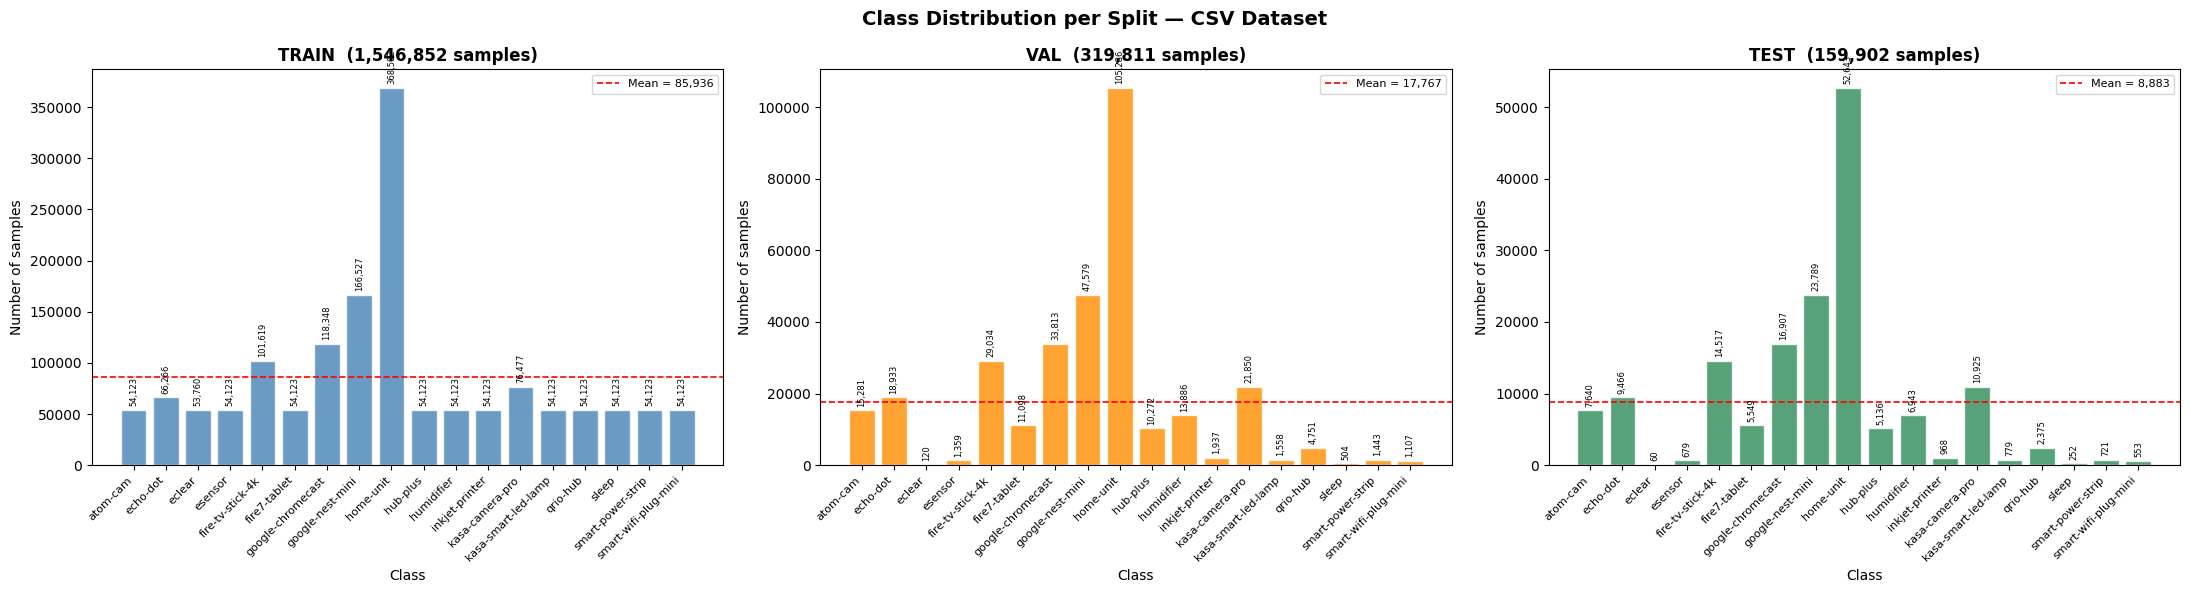


  [Saved] /content/drive/MyDrive/PFE/results/preprocessed/csv_smote/class_distribution_csv.png


In [4]:
# ─── Cell: Load CSV Dataset ───────────────────────────────────────────────────
import os
import pickle
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

CSV_BASE_DIR = f"{DRIVE_RESULTS_DIR}/preprocessed/csv"
CSV_BALANCED_DIR = f"{DRIVE_RESULTS_DIR}/preprocessed/csv_smote"
CSV_DIR = CSV_BALANCED_DIR if os.path.exists(f"{CSV_BALANCED_DIR}/csv_ready") else CSV_BASE_DIR

print(f"Loading CSV dataset from: {CSV_DIR}")

X_train = np.load(f"{CSV_DIR}/X_train.npy")
X_val = np.load(f"{CSV_DIR}/X_val.npy")
X_test = np.load(f"{CSV_DIR}/X_test.npy")
y_train = np.load(f"{CSV_DIR}/y_train.npy")
y_val = np.load(f"{CSV_DIR}/y_val.npy")
y_test = np.load(f"{CSV_DIR}/y_test.npy")

with open(f"{CSV_DIR}/csv_metadata.pkl", "rb") as f:
    metadata = pickle.load(f)

print(f"  X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}   | y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}  | y_test  : {y_test.shape}")

print("\nMetadata keys:", list(metadata.keys()))

if 'class_names' in metadata:
    label_names = metadata['class_names']
elif 'label_encoder' in metadata:
    label_names = metadata['label_encoder'].classes_
elif 'classes' in metadata:
    label_names = metadata['classes']
else:
    label_names = None
    print("  [!] Aucun label_names trouvé dans metadata — affichage class_0, class_1...")

print(f"  Classes : {label_names}")

print("=" * 70)
print("  CLASS DISTRIBUTION ANALYSIS — CSV DATASET")
print("=" * 70)

splits = {
    'TRAIN': y_train,
    'VAL': y_val,
    'TEST': y_test,
}

for split_name, y in splits.items():
    counter = Counter(y)
    total = len(y)
    n_cls = len(counter)

    print(f"\n{'─'*70}")
    print(f"  {split_name} SET — {total:,} samples | {n_cls} classes")
    print(f"{'─'*70}")
    print(f"  {'ID':>4} | {'Label':<35} | {'Count':>8} | {'%':>6} | Bar")
    print(f"  {'─'*4}-+-{'─'*35}-+-{'─'*8}-+-{'─'*6}-+-{'─'*25}")

    for cls_id, count in sorted(counter.items()):
        pct = 100.0 * count / total
        name = (
            label_names[cls_id]
            if label_names is not None and cls_id < len(label_names)
            else f"class_{cls_id}"
        )
        bar = "█" * int(pct / 2)
        print(f"  {cls_id:>4} | {name:<35} | {count:>8,} | {pct:>5.1f}% | {bar}")

    counts = np.array([counter[c] for c in sorted(counter)])
    ratio = counts.max() / (counts.min() + 1e-9)
    entropy = -np.sum((counts / total) * np.log2(counts / total + 1e-12))
    balance = entropy / np.log2(n_cls)

    print(f"\n  ► Total samples      : {total:,}")
    print(f"  ► Min samples/class  : {counts.min():,}  → class {np.argmin(counts)}"
          + (f" ({label_names[np.argmin(counts)]})" if label_names is not None else ""))
    print(f"  ► Max samples/class  : {counts.max():,}  → class {np.argmax(counts)}"
          + (f" ({label_names[np.argmax(counts)]})" if label_names is not None else ""))
    print(f"  ► Imbalance ratio    : {ratio:.1f}x  "
          f"({'✅ OK' if ratio < 5 else '⚠️  Moderate' if ratio < 20 else '🔴 Severe'})")
    print(f"  ► Balance score      : {balance:.3f}  "
          f"({'✅ OK' if balance > 0.85 else '⚠️  Moderate' if balance > 0.70 else '🔴 Severe'})")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("Class Distribution per Split — CSV Dataset", fontsize=14, fontweight='bold')

colors = ['steelblue', 'darkorange', 'seagreen']

for ax, (split_name, y), color in zip(axes, splits.items(), colors):
    counter = Counter(y)
    classes = sorted(counter.keys())
    counts = [counter[c] for c in classes]
    x_labels = (
        [label_names[c] for c in classes]
        if label_names is not None
        else [f"cls_{c}" for c in classes]
    )

    bars = ax.bar(range(len(classes)), counts, color=color, alpha=0.8, edgecolor='white')
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"{split_name}  ({len(y):,} samples)", fontweight='bold')
    ax.set_ylabel("Number of samples")
    ax.set_xlabel("Class")

    mean_count = np.mean(counts)
    ax.axhline(mean_count, color='red', linestyle='--', linewidth=1.2, label=f"Mean = {mean_count:,.0f}")
    ax.legend(fontsize=8)

    for bar, cnt in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.01,
            f"{cnt:,}",
            ha='center',
            va='bottom',
            fontsize=6,
            rotation=90,
        )

plt.tight_layout()
save_path = f"{CSV_DIR}/class_distribution_csv.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  [Saved] {save_path}")


✅ SMOTE cache found — loading from: /content/drive/MyDrive/PFE/results/preprocessed/csv_smote

  SMOTE VERIFICATION — TRAIN SPLIT (only train is resampled)

    ID | Label                          |   Before |    After |  Δ Added | % Before |  % After
  ────-+-──────────────────────────────-+-────────-+-────────-+-────────-+-────────-+-────────
     0 | atom-cam                       |   53,484 |   54,123 |     +639 |    4.78% |    3.50% ✚
     1 | echo-dot                       |   66,266 |   66,266 |       +0 |    5.92% |    4.28%
     2 | eclear                         |      420 |   53,760 |  +53,340 |    0.04% |    3.48% ✚
     3 | esensor                        |    4,757 |   54,123 |  +49,366 |    0.42% |    3.50% ✚
     4 | fire-tv-stick-4k               |  101,619 |  101,619 |       +0 |    9.08% |    6.57%
     5 | fire7-tablet                   |   38,844 |   54,123 |  +15,279 |    3.47% |    3.50% ✚
     6 | google-chromecast              |  118,348 |  118,348 |       +0 | 

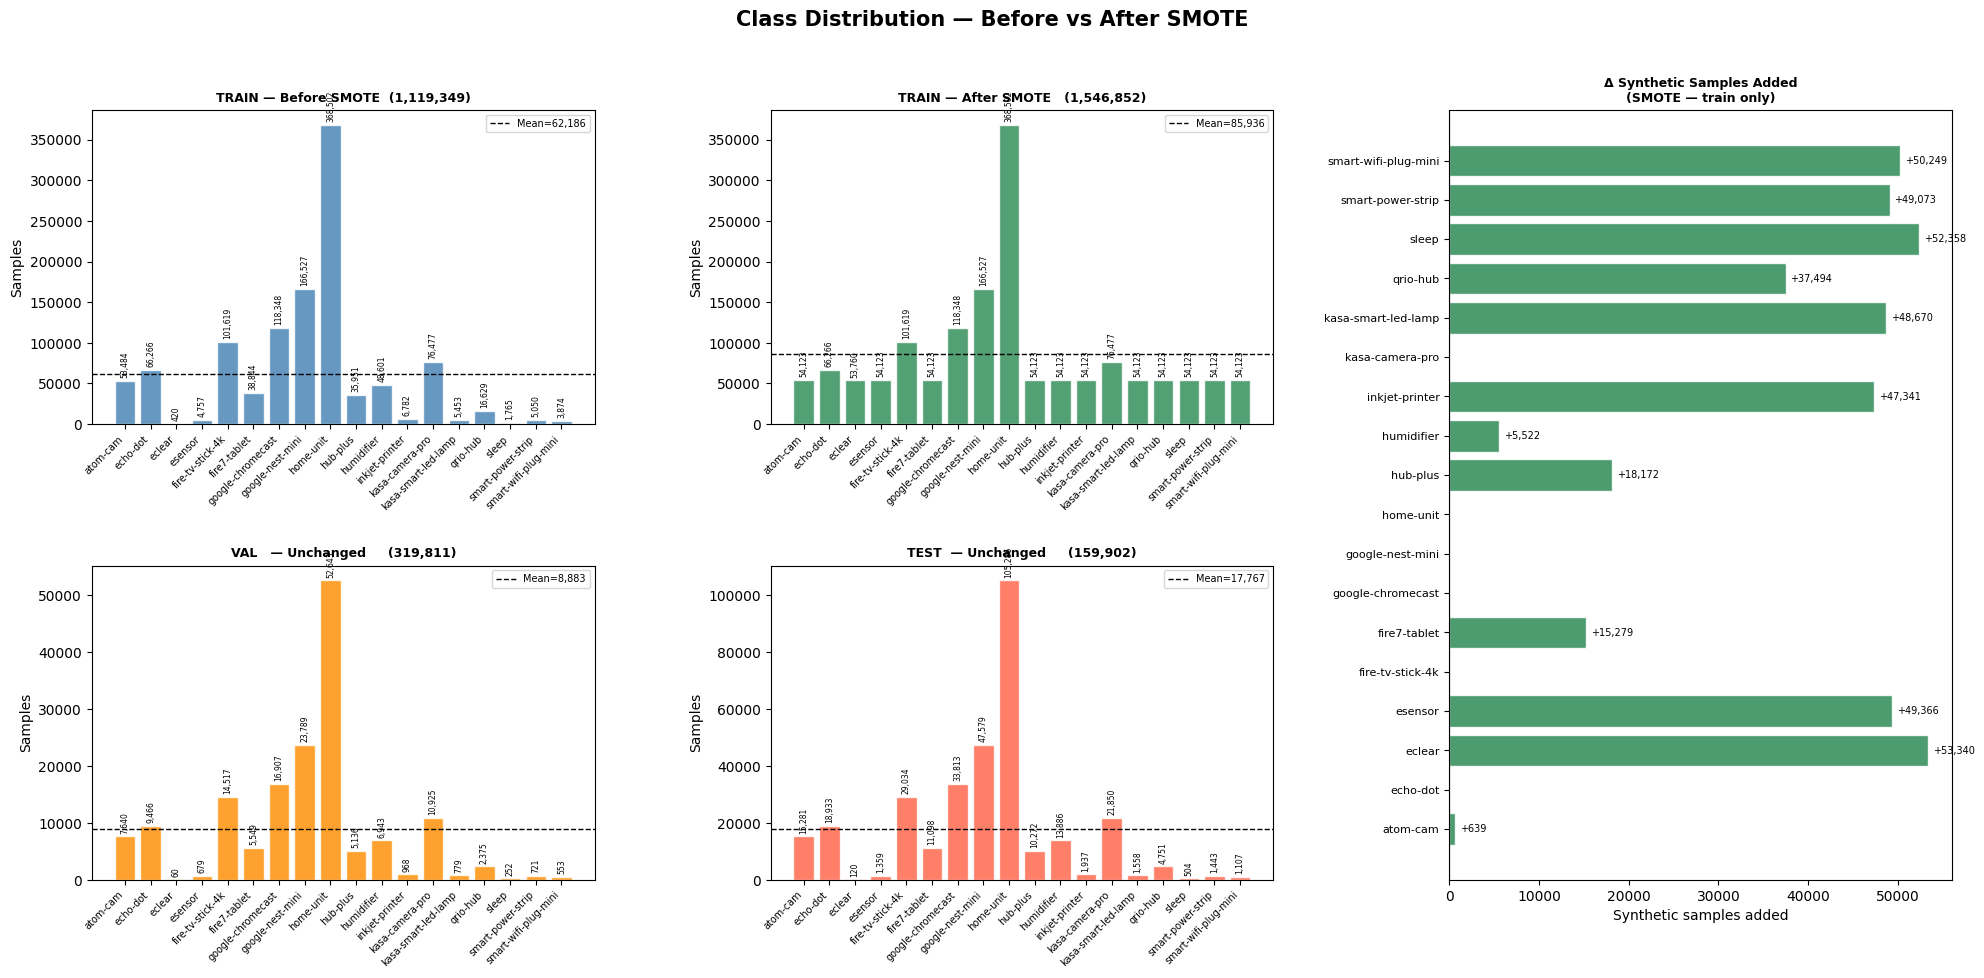


  [Saved] /content/drive/MyDrive/PFE/results/preprocessed/csv_smote/smote_verification.png

  Shapes after SMOTE:
    X_train : (1546852, 10, 16) | y_train : (1546852,)
    X_val   : (319811, 10, 16)   | y_val   : (319811,)
    X_test  : (159902, 10, 16)  | y_test  : (159902,)


In [5]:
# ─── Cell: Verify CSV Dataset After SMOTE ─────────────────────────────────────
import os
import pickle
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

CSV_BASE_DIR    = f"{DRIVE_RESULTS_DIR}/preprocessed/csv"
CSV_BALANCED_DIR = f"{DRIVE_RESULTS_DIR}/preprocessed/csv_smote"

smote_available = os.path.exists(f"{CSV_BALANCED_DIR}/X_train.npy")

# ── Load ORIGINAL (pre-SMOTE) ─────────────────────────────────────────────────
y_train_orig = np.load(f"{CSV_BASE_DIR}/y_train.npy")
y_val_orig   = np.load(f"{CSV_BASE_DIR}/y_val.npy")
y_test_orig  = np.load(f"{CSV_BASE_DIR}/y_test.npy")

# ── Load SMOTE-balanced ───────────────────────────────────────────────────────
if smote_available:
    X_train = np.load(f"{CSV_BALANCED_DIR}/X_train.npy")
    X_val   = np.load(f"{CSV_BALANCED_DIR}/X_val.npy")
    X_test  = np.load(f"{CSV_BALANCED_DIR}/X_test.npy")
    y_train = np.load(f"{CSV_BALANCED_DIR}/y_train.npy")
    y_val   = np.load(f"{CSV_BALANCED_DIR}/y_val.npy")
    y_test  = np.load(f"{CSV_BALANCED_DIR}/y_test.npy")

    with open(f"{CSV_BALANCED_DIR}/csv_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    CSV_DIR = CSV_BALANCED_DIR
    print(f"✅ SMOTE cache found — loading from: {CSV_BALANCED_DIR}")
else:
    X_train, X_val, X_test = [None]*3
    y_train, y_val, y_test = y_train_orig, y_val_orig, y_test_orig
    with open(f"{CSV_BASE_DIR}/csv_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)
    CSV_DIR = CSV_BASE_DIR
    print("⚠️  No SMOTE cache found — showing original only.")

# ── Label names ───────────────────────────────────────────────────────────────
if 'class_names' in metadata:
    label_names = metadata['class_names']
elif 'label_encoder' in metadata:
    label_names = metadata['label_encoder'].classes_
elif 'classes' in metadata:
    label_names = metadata['classes']
else:
    label_names = None

# ── Helper: balance metrics ───────────────────────────────────────────────────
def balance_metrics(counter, total):
    counts = np.array([counter[c] for c in sorted(counter)])
    n_cls  = len(counts)
    ratio  = counts.max() / (counts.min() + 1e-9)
    entropy = -np.sum((counts / total) * np.log2(counts / total + 1e-12))
    balance = entropy / np.log2(n_cls)
    return ratio, balance, counts

# ── Console report ────────────────────────────────────────────────────────────
print("\n" + "=" * 75)
print("  SMOTE VERIFICATION — TRAIN SPLIT (only train is resampled)")
print("=" * 75)

counter_orig = Counter(y_train_orig)
counter_smote = Counter(y_train)
all_classes = sorted(set(counter_orig) | set(counter_smote))
total_orig  = len(y_train_orig)
total_smote = len(y_train)

print(f"\n  {'ID':>4} | {'Label':<30} | {'Before':>8} | {'After':>8} | {'Δ Added':>8} | {'% Before':>8} | {'% After':>8}")
print(f"  {'─'*4}-+-{'─'*30}-+-{'─'*8}-+-{'─'*8}-+-{'─'*8}-+-{'─'*8}-+-{'─'*8}")

for cls_id in all_classes:
    orig_n  = counter_orig.get(cls_id, 0)
    smote_n = counter_smote.get(cls_id, 0)
    delta   = smote_n - orig_n
    pct_o   = 100.0 * orig_n  / total_orig
    pct_s   = 100.0 * smote_n / total_smote
    name    = (label_names[cls_id] if label_names is not None and cls_id < len(label_names)
               else f"class_{cls_id}")
    flag    = " ✚" if delta > 0 else ""
    print(f"  {cls_id:>4} | {name:<30} | {orig_n:>8,} | {smote_n:>8,} | {delta:>+8,} | {pct_o:>7.2f}% | {pct_s:>7.2f}%{flag}")

ratio_o, bal_o, _ = balance_metrics(counter_orig,  total_orig)
ratio_s, bal_s, _ = balance_metrics(counter_smote, total_smote)

print(f"\n  ┌─────────────────────────────────────────────────────────┐")
print(f"  │  Metric              │    Before SMOTE  │   After SMOTE  │")
print(f"  ├─────────────────────────────────────────────────────────┤")
print(f"  │  Total samples       │ {total_orig:>15,}  │ {total_smote:>13,}  │")
print(f"  │  Imbalance ratio     │ {ratio_o:>15.1f}x │ {ratio_s:>13.1f}x │")
print(f"  │  Balance score       │ {bal_o:>15.3f}  │ {bal_s:>13.3f}  │")
print(f"  └─────────────────────────────────────────────────────────┘")

imb_icon = lambda r: '✅ OK' if r < 5 else '⚠️  Moderate' if r < 20 else '🔴 Severe'
bal_icon = lambda b: '✅ OK' if b > 0.85 else '⚠️  Moderate' if b > 0.70 else '🔴 Severe'
print(f"\n  Imbalance  : {imb_icon(ratio_o)} → {imb_icon(ratio_s)}")
print(f"  Balance    : {bal_icon(bal_o)} → {bal_icon(bal_s)}")

# ── Plot: Before / After SMOTE (train only) + VAL & TEST unchanged ────────────
fig = plt.figure(figsize=(24, 10))
fig.suptitle("Class Distribution — Before vs After SMOTE", fontsize=15, fontweight='bold')

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

plot_configs = [
    # (row, col, y_data, title, color)
    (0, 0, y_train_orig, f"TRAIN — Before SMOTE  ({total_orig:,})",  "steelblue"),
    (0, 1, y_train,      f"TRAIN — After SMOTE   ({total_smote:,})", "seagreen"),
    (1, 0, y_val_orig,   f"VAL   — Unchanged     ({len(y_val):,})",  "darkorange"),
    (1, 1, y_test_orig,  f"TEST  — Unchanged     ({len(y_test):,})", "tomato"),
]

for row, col, y_data, title, color in plot_configs:
    ax = fig.add_subplot(gs[row, col])
    counter = Counter(y_data)
    classes = sorted(counter.keys())
    counts  = [counter[c] for c in classes]
    xlabels = (
        [label_names[c] for c in classes] if label_names is not None
        else [f"cls_{c}" for c in classes]
    )
    bars = ax.bar(range(len(classes)), counts, color=color, alpha=0.82, edgecolor='white')
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=7)
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_ylabel("Samples")
    mean_c = np.mean(counts)
    ax.axhline(mean_c, color='black', linestyle='--', linewidth=1, label=f"Mean={mean_c:,.0f}")
    ax.legend(fontsize=7)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                f"{cnt:,}", ha='center', va='bottom', fontsize=5.5, rotation=90)

# ── Delta plot (right column, spans both rows) ────────────────────────────────
ax_delta = fig.add_subplot(gs[:, 2])
deltas   = [counter_smote.get(c, 0) - counter_orig.get(c, 0) for c in all_classes]
xlabels  = (
    [label_names[c] for c in all_classes] if label_names is not None
    else [f"cls_{c}" for c in all_classes]
)
bar_colors = ["seagreen" if d > 0 else "lightgray" for d in deltas]
ax_delta.barh(range(len(all_classes)), deltas, color=bar_colors, edgecolor='white', alpha=0.85)
ax_delta.set_yticks(range(len(all_classes)))
ax_delta.set_yticklabels(xlabels, fontsize=8)
ax_delta.set_xlabel("Synthetic samples added")
ax_delta.set_title("Δ Synthetic Samples Added\n(SMOTE — train only)", fontweight='bold', fontsize=9)
ax_delta.axvline(0, color='black', linewidth=0.8)
for i, (d, cls_id) in enumerate(zip(deltas, all_classes)):
    if d > 0:
        ax_delta.text(d + max(deltas)*0.01, i, f"+{d:,}", va='center', fontsize=7)

save_path = f"{CSV_DIR}/smote_verification.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  [Saved] {save_path}")

# ── Shapes summary ────────────────────────────────────────────────────────────
if smote_available:
    print("\n  Shapes after SMOTE:")
    print(f"    X_train : {X_train.shape} | y_train : {y_train.shape}")
    print(f"    X_val   : {X_val.shape}   | y_val   : {y_val.shape}")
    print(f"    X_test  : {X_test.shape}  | y_test  : {y_test.shape}")


# Phase 3 : Greedy Adversarial Training Core

In [6]:
# ─── Cell: GreedyAttackSimulator + Training Functions ─────────────────────
import sys
sys.path.insert(0, '/content/pfe')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
import json
import os

from src.models.lstm import LSTMClassifier
from src.models.bilstm import BiLSTMClassifier
from src.models.cnn_lstm import CNNLSTMClassifier
from src.models.xgboost_lstm import XGBoostLSTMClassifier
from src.models.transformer import TransformerClassifier
from src.models.cnn_bilstm_transformer import CNNBiLSTMTransformerClassifier
from src.training.trainer import IoTSequenceDataset
from src.adversarial.robust_losses import AFDLoss


# =====================================================================
# FIXED: nlp_cnn_bilstm_transformer properly uses embedded layer logic
# GreedyAttackSimulator — replique exactement adversarial_search_seq.py
# =====================================================================
# FIXED: nlp_cnn_bilstm_transformer properly uses embedded layer logic

class GreedyAttackSimulator:
    def __init__(self, sensitivity_results, feature_stats, feature_names=None,
                 n_continuous=None, verbose=True):
        self.results = sensitivity_results
        self.stats = feature_stats
        self.feature_names = feature_names or []
        self.n_continuous = n_continuous

        self.feature_pool = {}
        self.feature_weights = {}
        epsilon = 0.05  # Exploratory minimum probability

        for fi, st, drop in sensitivity_results:
            if fi not in self.feature_pool:
                self.feature_pool[fi] = []
                self.feature_weights[fi] = max(0.0, drop) + epsilon

            # Maintain a pool of valid strategies even if drop <= 0, we keep them for exploratory testing
            self.feature_pool[fi].append(st)

        self.available_features = list(self.feature_pool.keys())
        if len(self.available_features) > 0:
            weights = np.array([self.feature_weights[f] for f in self.available_features])
            if weights.sum() > 0:
                self.sampling_probs = weights / weights.sum()
            else:
                self.sampling_probs = np.ones(len(weights)) / len(weights)
        else:
            self.sampling_probs = np.array([])

        # ─── Contraintes de réalisme (projection) ─────────────────────────
        self._build_constraints()

        if verbose:
            print(f"  [Simulator] Vulnerability Dictionary created with {len(self.available_features)} distinct features.")
            print(f"  [Simulator] Projection: {len(self.dependent_indices)} dependent pairs, "
                  f"n_continuous={self.n_continuous}")
            print(f"  [Simulator] Top 3 features logic overview:")
            for idx, feat in enumerate(self.available_features[:3]):
                print(f"     -> Feature {feat} mapped to {len(self.feature_pool[feat])} strategies (prob={self.sampling_probs[idx]:.3f})")

    def _build_constraints(self):
        """Build non-modifiable list and dependent pairs from feature names."""
        fnames = self.feature_names
        has_pkt_dir = any(f.startswith('pkt_dir_') for f in fnames)

        if has_pkt_dir:
            self.dependent_pairs = {
                'reversePacketTotalCount': 'packetTotalCount',
                'reverseOctetTotalCount': 'octetTotalCount',
                'reverseAverageInterarrivalTime': 'averageInterarrivalTime',
            }
        else:
            self.dependent_pairs = {
                'inPacketCount': 'outPacketCount',
                'inByteCount': 'outByteCount',
                'inAvgIAT': 'outAvgIAT',
                'inAvgPacketSize': 'outAvgPacketSize',
            }

        # Build index pairs (indep_idx, dep_idx)
        self.dependent_indices = []
        for dep_name, indep_name in self.dependent_pairs.items():
            if dep_name in fnames and indep_name in fnames:
                self.dependent_indices.append(
                    (fnames.index(indep_name), fnames.index(dep_name))
                )

    def projection(self, X):
        """Clip perturbed values to valid ranges and enforce dependent constraints."""
        X_proj = X.copy()
        n_cont = self.n_continuous

        # Clip continuous features to [-3, 3] and categorical to {0, 1}
        if n_cont is not None:
            if X_proj.ndim == 3:
                X_proj[:, :, :n_cont] = np.clip(X_proj[:, :, :n_cont], -3.0, 3.0)
                X_proj[:, :, n_cont:] = np.clip(np.round(X_proj[:, :, n_cont:]), 0, 1)
            elif X_proj.ndim == 2:
                X_proj[:, :n_cont] = np.clip(X_proj[:, :n_cont], -3.0, 3.0)
                X_proj[:, n_cont:] = np.clip(np.round(X_proj[:, n_cont:]), 0, 1)
        else:
            X_proj = np.clip(X_proj, -3.0, 3.0)

        # Enforce dependent feature correlations (ratio clamped to [0.5, 2.0])
        for indep_idx, dep_idx in self.dependent_indices:
            if n_cont is not None and (dep_idx >= n_cont or indep_idx >= n_cont):
                continue
            if X_proj.ndim == 3:
                ratio = np.abs(X_proj[:, :, dep_idx]) / (
                    np.abs(X_proj[:, :, indep_idx]) + 1e-8
                )
                X_proj[:, :, dep_idx] = X_proj[:, :, indep_idx] * np.clip(ratio, 0.5, 2.0)
            elif X_proj.ndim == 2:
                ratio = np.abs(X_proj[:, dep_idx]) / (
                    np.abs(X_proj[:, indep_idx]) + 1e-8
                )
                X_proj[:, dep_idx] = X_proj[:, indep_idx] * np.clip(ratio, 0.5, 2.0)

        return X_proj

    def save_dictionary(self, save_path, feature_names):
        dict_data = {
            "num_features": len(self.available_features),
            "features": {}
        }
        for feat_idx in self.available_features:
            feat_name = feature_names[feat_idx] if feat_idx < len(feature_names) else f"f{feat_idx}"
            dict_data["features"][feat_name] = {
                "strategies": self.feature_pool[feat_idx],
                "weight": float(self.feature_weights[feat_idx])
            }
        import os
        import json
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        with open(save_path, 'w') as f:
            json.dump(dict_data, f, indent=2)
        print(f"  [Simulator] Vulnerability Dictionary saved to {save_path}")

    @classmethod
    def compute_feature_stats(cls, X_train):
        X_flat = X_train.reshape(-1, X_train.shape[-1])
        stats = {}
        for i in range(X_flat.shape[1]):
            col = X_flat[:, i]
            stats[i] = {
                'mean': float(col.mean()),
                'p95': float(np.percentile(col, 95)),
                'std': float(col.std()),
            }
        return stats

    def apply_strategy(self, X, feat_idx, strategy):
        X = X.copy()
        if strategy == 'Zero':
            X[:, :, feat_idx] = 0.0
        elif strategy == 'Mimic_Mean':
            X[:, :, feat_idx] = self.stats[feat_idx]['mean']
        elif strategy == 'Mimic_95th':
            X[:, :, feat_idx] = self.stats[feat_idx]['p95']
        elif strategy == 'Padding_x10':
            X[:, :, feat_idx] = np.clip(X[:, :, feat_idx] * 10.0, -5.0, 5.0)
        return X

    def generate_greedy(self, X, k):
        """Méthode stochastique originale — sélection aléatoire pondérée de k features."""
        X_adv = X.copy()
        n_avail = len(self.available_features)
        if n_avail == 0:
            return X_adv

        k_actual = min(k, n_avail)
        chosen_features = np.random.choice(self.available_features, size=k_actual, replace=False, p=self.sampling_probs)

        for feat_idx in chosen_features:
            strategy = np.random.choice(self.feature_pool[feat_idx])
            X_adv = self.apply_strategy(X_adv, feat_idx, strategy)

        X_adv = self.projection(X_adv)
        return X_adv

    # ══════════════════════════════════════════════════════════════════════
    # MÉTHODE 3 — Stratified All-K Training (curriculum exhaustif par niveau)
    # Phase B : exhaustif k=1   → 100% couverture des attaques single-feature
    # Phase C : exhaustif k=1+2 → couverture des paires critiques
    # Phase D : exhaustif k=1+2 + worst-case k≥3 (Méthode 2, PGD-like)
    # ══════════════════════════════════════════════════════════════════════

    def generate_all_k1(self, X):
        """Génère TOUTES les attaques k=1 pour le batch X.

        Pour chaque paire (feature, strategy) du dictionnaire de vulnérabilités,
        crée une version adversariale du batch complet.
        Retourne (X_augmented, n_attacks) où X_augmented a n*(1+n_attacks) lignes
        (clean en premier, puis une copie par attaque).
        """
        all_X = []  # 100% adversarial — pas de copie clean
        for feat_idx in self.available_features:
            for strategy in self.feature_pool[feat_idx]:
                X_adv = self.apply_strategy(X.copy(), feat_idx, strategy)
                X_adv = self.projection(X_adv)
                all_X.append(X_adv)
        n_attacks = len(all_X)  # tous les elements sont adversariaux
        return np.concatenate(all_X, axis=0), n_attacks

    def generate_all_k2(self, X, top_n=8):
        """Génère toutes les attaques k=1 + les paires k=2 des top-N features.

        Pour les attaques k=2, utilise les top_n features les plus vulnérables
        (selon le dictionnaire trié par poids/sensibilité) avec leur stratégie
        la plus efficace (première du pool). Couvre les interactions de paires
        les plus dangereuses sans explosion combinatoire.
        """
        all_X = []  # 100% adversarial — pas de copie clean
        # k=1 : exhaustif sur tout le dictionnaire
        for feat_idx in self.available_features:
            for strategy in self.feature_pool[feat_idx]:
                X_adv = self.apply_strategy(X.copy(), feat_idx, strategy)
                all_X.append(self.projection(X_adv))
        # k=2 : paires des top-N features (meilleure stratégie de chacun)
        top_feats = self.available_features[:min(top_n, len(self.available_features))]
        for i, f1 in enumerate(top_feats):
            s1 = self.feature_pool[f1][0]
            for f2 in top_feats[i + 1:]:
                s2 = self.feature_pool[f2][0]
                X_adv = self.apply_strategy(X.copy(), f1, s1)
                X_adv = self.apply_strategy(X_adv, f2, s2)
                all_X.append(self.projection(X_adv))
        n_attacks = len(all_X)  # tous les elements sont adversariaux
        return np.concatenate(all_X, axis=0), n_attacks

    def generate_worst_case_k(self, X, y_np, model, device, k=3, n_candidates=8):
        """Sélection worst-case vectorisée parmi n_candidates attaques pour k features (Phase D).

        Optimisation: Génère l'attaque stochastique sur l'ensemble du batch simultanément
        et fait l'inférence en une seule passe sur le GPU. Vitesse x100 par rapport à l'original.
        """
        model.eval()
        N = len(X)
        best_X = X.copy()
        best_losses = np.full(N, -np.inf)

        y_t = torch.LongTensor(y_np).to(device)

        with torch.no_grad():
            for _ in range(n_candidates):
                # Génération pour tout le batch d'un coup (extrêmement rapide)
                X_cand = self.generate_greedy(X, k)
                X_t = torch.FloatTensor(X_cand).to(device)

                # Inférence massive GPU
                logits = model(X_t)

                # Pertes individuelles
                losses = F.cross_entropy(logits, y_t, reduction='none').cpu().numpy()

                # Mise à jour des meilleurs candidats
                mask = losses > best_losses
                best_losses[mask] = losses[mask]
                best_X[mask] = X_cand[mask]

        model.train()
        return best_X
    def generate_training_batch_stratified(self, X, y_np, model, device,
                                        phase='B1', k_max=4,
                                        mix_ratio=0.4, n_candidates=16,
                                        top_n_k2=12, k1_replay_ratio=0.5):
        """Curriculum v3 — phases B1/B2/C/D1/D2 avec ancrage progressif et replay.

        Ancrage : split clean/adv selon mix_ratio avant generation.
        Replay  : B2 garde k1_replay_ratio du budget adv en k=1.
        Adaptive: k1_replay_ratio ajuste dynamiquement dans train_model_greedy.
        """
        # ── Split clean/adv ──────────────────────────────────────────────────
        n_adv_total = int(len(X) * mix_ratio)
        n_clean = len(X) - n_adv_total
        X_clean = X[:n_clean]; y_clean = y_np[:n_clean]
        X_pool  = X[n_clean:]; y_pool  = y_np[n_clean:]

        parts_X = [X_clean] if n_clean > 0 else []
        parts_y = [y_clean] if n_clean > 0 else []

        if len(X_pool) == 0:
            return (np.concatenate(parts_X, axis=0) if parts_X else X.copy(),
                    np.concatenate(parts_y, axis=0) if parts_y else y_np.copy())

        if phase == 'B1':
            # 100% du budget adv -> k=1 exhaustif
            X_atk, n = self.generate_all_k1(X_pool)
            y_atk = np.tile(y_pool, n)[:len(X_atk)]
            if not getattr(self, '_logged_b1', False):
                print(f"  [B1] {n_clean} clean | {n} atk×{len(X_pool)} -> {len(X_atk)} adv | total={n_clean+len(X_atk)}")
                self._logged_b1 = True
            parts_X.append(X_atk); parts_y.append(y_atk)

        elif phase == 'B2':
            # k1_replay_ratio du budget adv -> k=1 (replay) ; reste -> k=2
            n_k1 = max(1, int(len(X_pool) * k1_replay_ratio))
            n_k2 = len(X_pool) - n_k1
            if n_k1 > 0:
                Xa, na = self.generate_all_k1(X_pool[:n_k1])
                parts_X.append(Xa); parts_y.append(np.tile(y_pool[:n_k1], na)[:len(Xa)])
            if n_k2 > 0:
                Xb, nb = self.generate_all_k2(X_pool[n_k1:], top_n=top_n_k2)
                parts_X.append(Xb); parts_y.append(np.tile(y_pool[n_k1:], nb)[:len(Xb)])
            if not getattr(self, '_logged_b2', False):
                total_adv = sum(len(p) for p in parts_X) - n_clean
                print(f"  [B2] {n_clean} clean | replay_k1={k1_replay_ratio:.0%} n_k1={n_k1} n_k2={n_k2} -> {total_adv} adv")
                self._logged_b2 = True

        elif phase == 'C':
            # 30% k=1, 30% k=2, 40% k=3 (worst-case)
            n = len(X_pool)
            n_k1 = int(n * 0.30); n_k2 = int(n * 0.30); n_k3 = n - n_k1 - n_k2
            if n_k1 > 0:
                Xa, na = self.generate_all_k1(X_pool[:n_k1])
                parts_X.append(Xa); parts_y.append(np.tile(y_pool[:n_k1], na)[:len(Xa)])
            if n_k2 > 0:
                s = n_k1 + n_k2
                Xb, nb = self.generate_all_k2(X_pool[n_k1:s], top_n=top_n_k2)
                parts_X.append(Xb); parts_y.append(np.tile(y_pool[n_k1:s], nb)[:len(Xb)])
            if n_k3 > 0:
                Xc = self.generate_worst_case_k(X_pool[n_k1+n_k2:], y_pool[n_k1+n_k2:],
                                            model, device, k=3, n_candidates=n_candidates)
                parts_X.append(Xc); parts_y.append(y_pool[n_k1+n_k2:].copy())
            if not getattr(self, '_logged_c', False):
                total = sum(len(p) for p in parts_X)
                print(f"  [C] {n_clean} clean | k1:{n_k1}+k2:{n_k2}+k3:{n_k3} -> total {total}")
                self._logged_c = True

        elif phase == 'D1':
            # 10% k=1, 10% k=2, 15% k=3, 65% k=4  (focus k4 — Fix1)
            n = len(X_pool)
            n_k1 = int(n*0.10); n_k2 = int(n*0.10)
            n_k3 = int(n*0.15); n_k4 = n - n_k1 - n_k2 - n_k3
            splits = [(n_k1, 1), (n_k2, 2), (n_k3, 3), (n_k4, 4)]
            idx = 0
            for sub_n, k_val in splits:
                if sub_n <= 0:
                    idx += sub_n; continue
                Xs = X_pool[idx:idx+sub_n]; ys = y_pool[idx:idx+sub_n]
                if k_val == 1:
                    Xa, na = self.generate_all_k1(Xs)
                    parts_X.append(Xa); parts_y.append(np.tile(ys, na)[:len(Xa)])
                elif k_val == 2:
                    Xa, na = self.generate_all_k2(Xs, top_n=top_n_k2)
                    parts_X.append(Xa); parts_y.append(np.tile(ys, na)[:len(Xa)])
                else:
                    Xwc = self.generate_worst_case_k(Xs, ys, model, device,
                                                 k=k_val, n_candidates=n_candidates)
                    parts_X.append(Xwc); parts_y.append(ys.copy())
                idx += sub_n
            if not getattr(self, '_logged_d1', False):
                total = sum(len(p) for p in parts_X)
                print(f"  [D1] {n_clean} clean | k1:{n_k1}+k2:{n_k2}+k3:{n_k3}+k4:{n_k4} -> total {total}")
                self._logged_d1 = True

        elif phase == 'D2':
            # Worst-case sur tous les k
            for k_val in range(1, k_max + 1):
                Xwc = self.generate_worst_case_k(X_pool, y_pool, model, device,
                                              k=k_val, n_candidates=n_candidates)
                parts_X.append(Xwc); parts_y.append(y_pool.copy())
            if not getattr(self, '_logged_d2', False):
                total = sum(len(p) for p in parts_X)
                print(f"  [D2] {n_clean} clean | worst-case k=1..{k_max} -> total {total}")
                self._logged_d2 = True

        else:
            # Fallback stochastique
            X_out = X.copy()
            idx_adv = np.random.choice(len(X), n_adv_total, replace=False)
            for i in idx_adv:
                k = np.random.randint(1, k_max + 1)
                X_out[[i]] = self.generate_greedy(X[[i]], k)
            return X_out, y_np.copy()

        return np.concatenate(parts_X, axis=0), np.concatenate(parts_y, axis=0)

    def generate_training_batch(self, X, k_max=4, mix_ratio=0.5):
        """Méthode stochastique originale — conservée pour Phase A et compatibilité."""
        n = len(X)
        n_adv = int(n * mix_ratio)
        idx_adv = np.random.choice(n, n_adv, replace=False)
        X_out = X.copy()
        flags = np.zeros(n, dtype=np.float32)
        for i in idx_adv:
            k = np.random.randint(1, k_max + 1)
            X_out[[i]] = self.generate_greedy(X[[i]], k)
            flags[i] = 1.0
        return X_out, flags

def load_sensitivity_results(csv_path, feature_names):
    df = pd.read_csv(csv_path).sort_values('drop', ascending=False)
    idx = {name: i for i, name in enumerate(feature_names)}
    result = []
    for _, row in df.iterrows():
        feat = row['feature']
        if feat in idx:
            result.append((idx[feat], row['strategy'], float(row['drop'])))
    print(f"  -> {len(result)} (feature, strategy) pairs loaded from sensitivity analysis")
    print(f"  Top 5 most vulnerable:")
    for i, (fi, st, dr) in enumerate(result[:5], 1):
        print(f"     {i}. {feature_names[fi]:<25} | {st:<14} | drop={dr*100:.1f}%")
    return result


def create_model(model_type, input_size, num_classes):
    if model_type == 'lstm':
        return LSTMClassifier(input_size, num_classes)
    elif model_type == 'bilstm':
        return BiLSTMClassifier(input_size, num_classes)
    elif model_type == 'cnn_lstm':
        return CNNLSTMClassifier(input_size, num_classes)
    elif model_type == 'xgboost_lstm':
        return XGBoostLSTMClassifier(input_size, num_classes)
    elif model_type == 'transformer':
        return TransformerClassifier(input_size, num_classes)
    elif model_type == 'cnn_bilstm_transformer':
        return CNNBiLSTMTransformerClassifier(input_size, num_classes, seq_length=SEQ_LENGTH,
                                          config=CNN_BILSTM_TRANSFORMER_OVERRIDE)
    elif model_type == 'nlp_cnn_bilstm_transformer':
        return CNNBiLSTMTransformerClassifier(input_size=128, num_classes=num_classes, seq_length=576, vocab_size=52000, config=CNN_BILSTM_TRANSFORMER_OVERRIDE)
    else:
        raise ValueError(f"Unknown model type: {model_type}")


# =====================================================================
# FIXED: nlp_cnn_bilstm_transformer properly uses embedded layer logic
# train_greedy_phase — train model for one phase (A/B/C)
# =====================================================================
# FIXED: nlp_cnn_bilstm_transformer properly uses embedded layer logic

def train_greedy_phase(
    model, X_train, y_train, X_val, y_val,
    phase, max_epochs=20,
    mix_ratio=0.4, k_max=2,
    p_drop=0.0, sigma_noise=0.0,
    simulator=None, device=None,
    lr=5e-4, batch_size=64, save_path=None,
    is_nlp=False, tokenizer=None, features=None,
    adv_method='stratified', n_candidates=16, top_n_k2=12,
    k1_replay_ratio=0.5,
    threshold_ks=None, threshold_acc=0.85,
    stable_ks=None,     stable_acc=0.82,
):
    # adv_method: 'stochastic'  → méthode originale (Phase A)
    #             'stratified'  → Méthode 3 curriculum exhaustif
    #               Phase B: exhaustif k=1
    #               Phase C: exhaustif k=1 + k=2 top-8 paires
    #               Phase D: exhaustif k=1+k=2 + worst-case k=3,4 (PGD-like)
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(max_epochs, 1), eta_min=1e-6
    )
    use_amp = USE_AMP and device.type == 'cuda'
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


    train_ds = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=0, pin_memory=True)

    phase_names = {'A': 'Fondation (clean only)', 'B': 'Introduction (30% adv, k_max=2)', 'C': 'Principal (70% adv, k_max=4)', 'D': 'Consolidation (85% adv, k_max=4, epochs 51-80)'}
    adv_method_desc = {
        'stochastic':  'Stochastique (original) — k features tirées aléatoirement',
        'stratified':  {
            'A': 'Stochastique (Phase A — clean only)',
            'B': 'STRATIFIED k=1 exhaustif — 100% couverture single-feature',
            'C': 'STRATIFIED k=1+k=2 exhaustif — paires top-8 features',
            'D': 'STRATIFIED k=1+k=2 exhaustif + WORST-CASE k=3,4 (PGD-like)',
        },
    }
    if adv_method == 'stratified':
        method_label = adv_method_desc['stratified'].get(phase, 'stratified')
    else:
        method_label = adv_method_desc.get(adv_method, adv_method)

    print(f"\n{'='*60}")
    print(f"  PHASE {phase} — max {max_epochs} epochs")
    print(f"  {phase_names.get(phase, '')}")
    print(f"  mix_ratio={mix_ratio} | k_max={k_max}")
    print(f"  ADV METHOD : {method_label}")
    print(f"{'='*60}")

    best_val_acc = 0.0
    best_combined = 0.0   # score = 0.4*clean + 0.6*adv (phases adv seulement)
    best_epoch = 1

    epoch_dir = save_path.replace('.pt', '_epochs') if save_path else None
    if epoch_dir and os.path.exists(epoch_dir):
        saved_files = [f for f in os.listdir(epoch_dir) if f.startswith('epoch_') and f.endswith('.pt')]
        if saved_files:
            epochs_present = [int(f.replace('epoch_', '').replace('.pt', '')) for f in saved_files]
            last_saved = max(epochs_present)
            print(f"  [Resumption] Reprise de l'entraînement à partir de l'époque {last_saved+1}...")
            ckpt = torch.load(f"{epoch_dir}/epoch_{last_saved}.pt", map_location=device)
            model.load_state_dict(ckpt['model_state_dict'])
            best_val_acc = ckpt.get('best_val_acc', 0.0)
            best_combined = ckpt.get('best_combined', 0.0)
            best_epoch = ckpt.get('best_epoch', last_saved)

    label_sm_map = {'A': 0.05, 'B': 0.08, 'C': 0.10}
    label_sm = label_sm_map.get(phase, 0.05)

    best_metrics = {'clean': 0.0}
    consecutive_ok = 0
    _resume_from = last_saved + 1 if 'last_saved' in dir() else 1
    for epoch in range(_resume_from, max_epochs + 1):
        nan_batches = 0  # anti-NaN counter
        model.train()
        criterion = nn.CrossEntropyLoss(label_smoothing=label_sm)

        total_loss, total_correct, total_n = 0.0, 0, 0


        for batch_idx, (X_batch, y_batch) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch}", leave=False)):
            X_np = X_batch.numpy()
            y_input = y_batch.to(device)
            optimizer.zero_grad(set_to_none=True)

            if mix_ratio > 0 and simulator is not None:
                # ── Génération adversariale stratifiée ou stochastique ───────────
                if adv_method == 'stratified' and phase in ('B', 'C', 'D'):
                    y_np_batch = y_batch.numpy()
                    # It's better to NOT use autocast during generation inside this loop to avoid nested/missed casts unless it's within the inner model forward, but we'll leave the autocast context to generation itself.
                    # Wait, generation calls model(...) which expects the correct types.
                    with torch.amp.autocast('cuda', enabled=use_amp):
                        X_mixed, y_mixed_np = simulator.generate_training_batch_stratified(
                            X_np, y_np_batch, model, device,
                            phase=phase, k_max=k_max, mix_ratio=mix_ratio,
                            n_candidates=n_candidates, top_n_k2=top_n_k2,
                        )
                    y_input = torch.LongTensor(y_mixed_np).to(device)
                else:
                    X_mixed, _ = simulator.generate_training_batch(X_np, k_max=k_max, mix_ratio=mix_ratio)
                    y_input = y_batch.to(device)
            else:
                X_mixed = X_np
                y_input = y_batch.to(device)

            # ── Memory-efficient chunked forward/backward ───────────────────
            chunk_sz = batch_size
            n_chunks = (len(X_mixed) + chunk_sz - 1) // chunk_sz

            batch_loss = 0.0
            batch_correct = 0
            skip_batch = False

            for c_idx in range(n_chunks):
                start = c_idx * chunk_sz
                end = min(start + chunk_sz, len(X_mixed))
                X_chunk = X_mixed[start:end]
                y_chunk_input = y_input[start:end]

                with torch.amp.autocast('cuda', enabled=use_amp):
                    if is_nlp:
                        X_input_chunk = torch.LongTensor(tokenizer.transform(X_chunk, features)).to(device)
                    else:
                        X_input_chunk = torch.FloatTensor(X_chunk).to(device)

                    if p_drop > 0 and not is_nlp:
                        mask = (torch.rand(X_input_chunk.shape[0], 1, X_input_chunk.shape[2], device=device) > p_drop).float()
                        X_input_chunk = X_input_chunk * mask / (1.0 - p_drop)
                    if sigma_noise > 0:
                        X_input_chunk = X_input_chunk + torch.randn_like(X_input_chunk) * sigma_noise

                    logits_chunk = model(X_input_chunk)
                    loss_chunk = criterion(logits_chunk, y_chunk_input) * (len(X_chunk) / len(X_mixed))

                if torch.isnan(loss_chunk) or torch.isinf(loss_chunk):
                    skip_batch = True
                    break

                scaler.scale(loss_chunk).backward()

                batch_loss += loss_chunk.item() * (len(X_mixed) / max(1, len(X_chunk))) * (len(X_chunk) / len(X_mixed)) # which is loss_chunk.item() without scaling down? Wait.
                # Actually, loss_chunk is already scaled down. So its value is the contribution to the total mean loss.
                # If we sum it, we get the total mean loss for the whole X_mixed batch.
                batch_loss += loss_chunk.item()
                batch_correct += (logits_chunk.argmax(1) == y_chunk_input).sum().item()

            if skip_batch:
                nan_batches += 1
                optimizer.zero_grad()
                continue

            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            scaler.step(optimizer)
            scaler.update()

            total_loss += batch_loss * len(X_mixed)
            total_correct += batch_correct
            total_n += len(X_mixed)

        scheduler.step()
        if device.type == 'cuda':
            torch.cuda.empty_cache()

        train_loss = total_loss / total_n
        train_acc = total_correct / total_n

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for i in range(0, len(X_val), batch_size):
                end = min(i + batch_size, len(X_val))
                if is_nlp:
                    X_val_t = torch.LongTensor(tokenizer.transform(X_val[i:end], features)).to(device)
                else:
                    X_val_t = torch.FloatTensor(X_val[i:end]).to(device)
                y_val_t = torch.LongTensor(y_val[i:end]).to(device)
                val_correct += (model(X_val_t).argmax(1) == y_val_t).sum().item()
                val_total += len(y_val_t)
            val_clean_acc = val_correct / val_total

            val_adv_acc = 0.0
            val_adv_acc_k = {}
            if simulator is not None and k_max > 0:
                n_eval = min(EVAL_SUBSAMPLE, len(X_val))
                # Stratified random sampling for epoch-level adv eval
                _rng = np.random.RandomState(epoch)  # epoch seed → different each epoch
                _uq = np.unique(y_val)
                _per_c = max(1, n_eval // len(_uq))
                _eval_idx = np.concatenate([
                    _rng.choice(np.where(y_val == c)[0],
                               min(_per_c, (y_val == c).sum()), replace=False)
                    for c in _uq
                ])[:n_eval]
                for k_val in range(1, k_max + 1):
                    val_adv_correct = 0
                    for i in range(0, len(_eval_idx), batch_size):
                        end = min(i + batch_size, len(_eval_idx))
                        X_adv_np = simulator.generate_greedy(X_val[_eval_idx[i:end]], k=k_val)
                        if is_nlp:
                            X_adv_t = torch.LongTensor(tokenizer.transform(X_adv_np, features)).to(device)
                        else:
                            X_adv_t = torch.FloatTensor(X_adv_np).to(device)
                        y_sub = torch.LongTensor(y_val[_eval_idx[i:end]]).to(device)
                        val_adv_correct += (model(X_adv_t).argmax(1) == y_sub).sum().item()
                    val_adv_acc_k[k_val] = val_adv_correct / n_eval
                val_adv_acc = val_adv_acc_k[k_max]

        adv_str = " ".join([f"k{k}={acc:.4f}" for k, acc in val_adv_acc_k.items()]) if simulator else ""
        if nan_batches > 0:
            print(f"  [WARN] {nan_batches} NaN batches skipped this epoch")
        print(f"  Epoch {epoch:3d}/{max_epochs} [Ph{phase}] "
              f"Loss={train_loss:.4f} TrainAcc={train_acc:.4f} "
              f"CleanAcc={val_clean_acc:.4f} AdvAcc={val_adv_acc:.4f}  {adv_str}")

        # ── Mise à jour des métriques et threshold gate ──────────────────
        cur_metrics = {'clean': val_clean_acc}
        cur_metrics.update({f'k{k}': v for k, v in val_adv_acc_k.items()})

        # Meilleur score = moyenne des k ciblés (ou clean si phase 0)
        if not threshold_ks:
            selection_score = val_clean_acc
            is_better = val_clean_acc > best_val_acc
        else:
            selection_score = sum(cur_metrics.get(f'k{k}', 0) for k in threshold_ks) / len(threshold_ks)
            is_better = selection_score > best_combined

        if is_better:
            best_val_acc = val_clean_acc
            best_combined = selection_score
            best_epoch = epoch
            best_metrics = cur_metrics

        # ── Threshold gate ────────────────────────────────────────────
        thr_ok = bool(threshold_ks) and all(cur_metrics.get(f'k{k}', 0) >= threshold_acc for k in threshold_ks)
        stable_ok = bool(stable_ks) and all(cur_metrics.get(f'k{k}', 0) >= stable_acc for k in stable_ks)
        clean_ok = (not threshold_ks) and val_clean_acc >= threshold_acc
        if math.isnan(train_loss) or math.isinf(train_loss):
            print(f"  [WARNING] Epoch loss is NaN! Skipping gate checks and discarding checkpoint.")
            thr_ok, stable_ok, clean_ok, is_better = False, False, False, False

        if (thr_ok and stable_ok) or clean_ok:
            consecutive_ok += 1
            print(f"  [Gate OK] epoch {epoch} — threshold met ({consecutive_ok}/1)")
            # Save best and exit immediately for single-k gates
            break
        else:
            consecutive_ok = 0
            if save_path:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'val_clean_acc': val_clean_acc,
                    'val_adv_acc': val_adv_acc,
                    'phase': phase,
                    'combined_score': selection_score,
                }, save_path)

        if save_path:
            epoch_dir = save_path.replace('.pt', '_epochs')
            os.makedirs(epoch_dir, exist_ok=True)
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_clean_acc': val_clean_acc,
                'val_adv_acc': val_adv_acc,
                'best_val_acc': best_val_acc,
                'best_combined': best_combined,
                'best_epoch': best_epoch,
            }, f"{epoch_dir}/epoch_{epoch}.pt")

    print(f"  Best epoch: {best_epoch} | score={best_combined:.4f} | "
          f"clean={best_val_acc:.4f}")

    if save_path and os.path.exists(save_path):
        ckpt = torch.load(save_path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])

    return model, best_metrics


# =====================================================================
# FIXED: nlp_cnn_bilstm_transformer properly uses embedded layer logic
# crash_test_greedy — evaluate clean + adversarial (k=1..4)
# =====================================================================
# FIXED: nlp_cnn_bilstm_transformer properly uses embedded layer logic

def crash_test_greedy(model, X_val, y_val, simulator, device=None,
                      k_values=None, label='', is_nlp=False, tokenizer=None, features=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if k_values is None:
        k_values = [1, 2, 3, 4]

    model.eval()
    model = model.to(device)

    n_eval = min(EVAL_SUBSAMPLE, len(X_val))
    # Stratified random sampling — avoid bias from first N samples
    rng = np.random.RandomState(42)
    unique_classes = np.unique(y_val)
    per_class = max(1, n_eval // len(unique_classes))
    eval_indices = []
    for c in unique_classes:
        c_idx = np.where(y_val == c)[0]
        chosen = rng.choice(c_idx, min(per_class, len(c_idx)), replace=False)
        eval_indices.extend(chosen.tolist())
    eval_indices = np.array(eval_indices[:n_eval])
    X_eval = X_val[eval_indices]
    y_eval = y_val[eval_indices]

    clean_correct = 0
    with torch.no_grad():
        for i in range(0, n_eval, 1024):
            end = min(i + 1024, n_eval)
            X_b = torch.LongTensor(tokenizer.transform(X_eval[i:end], features)).to(device) if is_nlp else torch.FloatTensor(X_eval[i:end]).to(device)
            y_b = torch.LongTensor(y_eval[i:end]).to(device)
            clean_correct += (model(X_b).argmax(1) == y_b).sum().item()
    clean_acc = clean_correct / n_eval

    results = {'clean': clean_acc}

    print(f"  [Crash Test {label}] Clean={clean_acc:.4f}", end='')

    if simulator is not None:
        for k in k_values:
            adv_correct = 0
            with torch.no_grad():
                for i in range(0, n_eval, 1024):
                    end = min(i + 1024, n_eval)
                    X_adv = simulator.generate_greedy(X_eval[i:end], k=k)
                    X_adv_t = torch.LongTensor(tokenizer.transform(X_adv, features)).to(device) if is_nlp else torch.FloatTensor(X_adv).to(device)
                    y_b = torch.LongTensor(y_eval[i:end]).to(device)
                    adv_correct += (model(X_adv_t).argmax(1) == y_b).sum().item()

            adv_acc = adv_correct / n_eval
            results[f'adv_k{k}'] = adv_acc
            rr = adv_acc / max(clean_acc, 1e-8)
            print(f" | k={k}: {adv_acc:.4f}(RR={rr:.3f})", end='')

    print()
    return results


# =====================================================================
# FIXED: nlp_cnn_bilstm_transformer properly uses embedded layer logic
# run_sensitivity_analysis — run sensitivity_analysis_seq.py logic
# =====================================================================
# FIXED: nlp_cnn_bilstm_transformer properly uses embedded layer logic

def run_sensitivity_analysis(model, X_val, y_val, feature_names, num_classes,
                         n_continuous, save_csv_path, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print(f"\n  Running sensitivity analysis...")
    model.eval()
    model = model.to(device)

    from src.adversarial.attacks import SensitivityAnalysis

    n_sens = min(5000, len(X_val))
    sens_indices = np.random.choice(len(X_val), n_sens, replace=False)
    X_sens = X_val[sens_indices].copy()
    y_sens = y_val[sens_indices].copy()

    sa = SensitivityAnalysis(
        X_sens, y_sens,
        feature_names if feature_names else [f'f{i}' for i in range(X_val.shape[2])],
        num_classes,
        n_continuous_features=n_continuous,
    )

    results = sa.analyze(model, X_sens, y_sens, device=device)

    rows = []
    for entry in results:
        rows.append({
            'feature': entry['feature'],
            'strategy': entry['strategy'],
            'drop': entry['drop'],
            'original_acc': entry.get('original_acc', 0) if 'original_acc' in entry else (entry['accuracy'] + entry['drop']),
            'perturbed_acc': entry['accuracy'],
        })

    df = pd.DataFrame(rows).sort_values('drop', ascending=False)
    os.makedirs(os.path.dirname(save_csv_path), exist_ok=True)
    df.to_csv(save_csv_path, index=False)
    print(f"  Sensitivity results saved to {save_csv_path}")
    print(f"  Top 5 vulnerable features:")
    for _, row in df.head(5).iterrows():
        print(f"    {row['feature']:<25} | {row['strategy']:<14} | drop={row['drop']*100:.1f}%")

    return df


# =====================================================================
# FIXED: nlp_cnn_bilstm_transformer properly uses embedded layer logic
# Discriminator and Router
# =====================================================================
# FIXED: nlp_cnn_bilstm_transformer properly uses embedded layer logic

class Discriminator(nn.Module):
    def __init__(self, input_size, seq_length, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_size * 2, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_cat = torch.cat([h[0], h[1]], dim=1)
        return self.head(h_cat).squeeze(1)

    def predict_proba(self, x):
        with torch.no_grad():
            return torch.sigmoid(self.forward(x))

def train_discriminator(discriminator, X_train, simulator, device=None, epochs=25, batch_size=64, lr=1e-3, save_path='discriminator.pt'):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n{'='*65}\n  ENTRAÎNEMENT DU DISCRIMINATEUR\n{'='*65}")
    discriminator = discriminator.to(device)
    optimizer = torch.optim.AdamW(discriminator.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss()
    n = len(X_train)
    best_acc = 0.0
    for epoch in range(1, epochs + 1):
        discriminator.train()
        n_half = n // 2
        idx = np.random.permutation(n)
        idx_clean = idx[:n_half]
        idx_adv = idx[n_half:n_half*2]
        k_values = np.random.randint(1, 4, size=n_half)
        X_adv_list = []
        for orig_i, k in zip(idx_adv, k_values):
            X_adv_list.append(simulator.generate_greedy(X_train[[orig_i]], k=k))
        X_adv_ep = np.concatenate(X_adv_list, axis=0)
        X_combined = np.concatenate([X_train[idx_clean], X_adv_ep], axis=0)
        labels_bin = np.array([0.0]*n_half + [1.0]*n_half, dtype=np.float32)
        perm = np.random.permutation(len(X_combined))
        X_combined = X_combined[perm]
        labels_bin = labels_bin[perm]
        loader = DataLoader(TensorDataset(torch.FloatTensor(X_combined), torch.FloatTensor(labels_bin)), batch_size=batch_size, shuffle=True)
        total_loss, total_correct, total_n = 0.0, 0, 0
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = discriminator(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
            optimizer.step()
            preds = (torch.sigmoid(logits) > 0.5).float()
            total_correct += (preds == yb).sum().item()
            total_loss += loss.item() * len(yb)
            total_n += len(yb)
        acc = total_correct / total_n
        print(f"  Epoch {epoch:3d}/{epochs}  Loss={total_loss/total_n:.4f}  Acc={acc:.4f}")
        if acc > best_acc:
            best_acc = acc
            torch.save({'model_state_dict': discriminator.state_dict(), 'accuracy': acc}, save_path)
    print(f"\n  Discriminateur — meilleure accuracy : {best_acc:.4f}\n  Sauvegardé → {save_path}")
    ckpt = torch.load(save_path, map_location=device)
    discriminator.load_state_dict(ckpt['model_state_dict'])
    return discriminator, best_acc

class IoTRouter(nn.Module):
    def __init__(self, normal_model, adversarial_model, discriminator, threshold=0.5, is_nlp=False, tokenizer=None, features=None):
        self.is_nlp = is_nlp
        self.tokenizer = tokenizer
        self.features = features
        super().__init__()
        self.normal = normal_model
        self.adversarial = adversarial_model
        self.discriminator = discriminator
        self.threshold = threshold

    @torch.no_grad()
    def predict(self, X):
        self.normal.eval()
        self.adversarial.eval()
        self.discriminator.eval()
        attack_scores = self.discriminator.predict_proba(X)
        is_attacked = (attack_scores >= self.threshold)
        logits_normal = self.normal(X)
        if hasattr(self, 'is_nlp') and self.is_nlp and self.tokenizer is not None:
            # Need X as numpy for tokenizer
            X_np = X.cpu().numpy()
            X_ids = self.tokenizer.transform(X_np, self.features)
            X_adj = torch.LongTensor(X_ids).to(X.device)
            logits_adv = self.adversarial(X_adj)
        else:
            logits_adv = self.adversarial(X)
        pred_normal = logits_normal.argmax(1)
        pred_adv = logits_adv.argmax(1)
        predictions = torch.where(is_attacked, pred_adv, pred_normal)
        routes = is_attacked.long()
        return predictions, routes, attack_scores

    def calibrate_threshold(self, X_clean, X_attacked, target_recall=0.95):
        with torch.no_grad():
            scores_clean = self.discriminator.predict_proba(X_clean).cpu().numpy()
            scores_attacked = self.discriminator.predict_proba(X_attacked).cpu().numpy()
        all_scores = np.concatenate([scores_clean, scores_attacked])
        all_labels = np.array([0]*len(scores_clean) + [1]*len(scores_attacked))
        thresholds = np.linspace(0.0, 1.0, 200)
        best_t, best_f1 = 0.5, 0.0
        for t in thresholds:
            preds = (all_scores >= t).astype(int)
            tp = ((preds == 1) & (all_labels == 1)).sum()
            fp = ((preds == 1) & (all_labels == 0)).sum()
            fn = ((preds == 0) & (all_labels == 1)).sum()
            recall = tp / (tp + fn + 1e-8)
            precision = tp / (tp + fp + 1e-8)
            f1 = 2 * precision * recall / (precision + recall + 1e-8)
            if recall >= target_recall and f1 > best_f1:
                best_f1 = f1
                best_t = t
        self.threshold = best_t
        print(f"  Seuil calibré : {best_t:.3f}  (recall attaques ≥ {target_recall:.0%})")
        return best_t

# =====================================================================
# FIXED: nlp_cnn_bilstm_transformer properly uses embedded layer logic
# train_model_greedy — orchestrate full 3-phase training for one model
# =====================================================================
# FIXED: nlp_cnn_bilstm_transformer properly uses embedded layer logic

def train_model_greedy(
    model_type, dataset_type, data_dict,
    batch_size=64, lr=5e-4,
):
    """Curriculum v3 — 6 phases threshold-gated avec replay et back-stepping D2->D1."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    save_dir = f'{DRIVE_RESULTS_DIR}/models/{model_type}_greedy_{dataset_type}'
    os.makedirs(save_dir, exist_ok=True)

    X_train = data_dict['X_train']; X_val = data_dict['X_val']; X_test = data_dict['X_test']
    y_train = data_dict['y_train']; y_val = data_dict['y_val']; y_test = data_dict['y_test']
    features      = data_dict.get('features', [])
    n_continuous  = data_dict.get('n_continuous', X_train.shape[2])
    input_size    = X_train.shape[2]
    num_classes   = len(np.unique(y_train))
    is_nlp        = ('nlp' in model_type)
    tokenizer     = None

    print(f"\n{'#'*80}")
    print(f"  GREEDY v3 — {model_type.upper()} on {dataset_type.upper()}")
    print(f"{'#'*80}")
    print(f"  Input: {input_size} | Classes: {num_classes} | Train: {len(X_train):,}")
    all_crash_results = {}
    feature_names = features if features else [f'f{i}' for i in range(input_size)]

    # ── Phase 0 Bootstrap ────────────────────────────────────────────────────
    ph0_path = f'{save_dir}/phase0_model.pt'
    sens_csv  = f'{save_dir}/sensitivity_results.csv'
    model = create_model(model_type, input_size, num_classes).to(device)

    # Compatibility Check
    if os.path.exists(ph0_path):
        try:
            model.load_state_dict(torch.load(ph0_path, map_location=device)['model_state_dict'])
        except RuntimeError:
            print(f"\n  [!] Checkpoint incompatible (input features changed). Deleting old checkpoints...")
            import shutil
            shutil.rmtree(save_dir)
            os.makedirs(save_dir, exist_ok=True)

    if os.path.exists(ph0_path):
        print(f"\n  Phase 0 model found. Loading...")
    else:
        print(f"\n  Phase 0 — Bootstrap (clean only, max {MAX_PHASE_EPOCHS} ep, gate CleanAcc>={K_THRESHOLD})")
        model, _ = train_greedy_phase(
            model, X_train, y_train, X_val, y_val,
            phase='0', max_epochs=MAX_PHASE_EPOCHS,
            mix_ratio=PHASE_0_MIX_RATIO, k_max=0,
            simulator=None, device=device, lr=lr,
            batch_size=batch_size, save_path=ph0_path,
            is_nlp=is_nlp, tokenizer=tokenizer, features=features,
            threshold_ks=None, threshold_acc=K_THRESHOLD,
        )

    # Sensitivity analysis — UNIQUE pour toutes les phases
    if os.path.exists(sens_csv):
        sensitivity = load_sensitivity_results(sens_csv, feature_names)
    else:
        run_sensitivity_analysis(model, X_val, y_val, feature_names, num_classes,
                              n_continuous, sens_csv, device=device)
        sensitivity = load_sensitivity_results(sens_csv, feature_names)

    feature_stats = GreedyAttackSimulator.compute_feature_stats(X_train)
    simulator = GreedyAttackSimulator(sensitivity, feature_stats,
                                   feature_names=feature_names, n_continuous=n_continuous)
    simulator.save_dictionary(f'{save_dir}/vulnerability_dictionary.json', feature_names)

    def _load_or_train(path, phase_name, mix_ratio, k_max, threshold_ks, threshold_acc,
                       stable_ks=None, stable_acc=K_STABLE, k1_replay_ratio=0.5):
        nonlocal model
        log_attr = f'_logged_{phase_name.lower()}'
        if hasattr(simulator, log_attr):
            setattr(simulator, log_attr, False)
        if os.path.exists(path):
            try:
                ckpt = torch.load(path, map_location=device)
                model.load_state_dict(ckpt['model_state_dict'])
                print(f"\n  {phase_name} model found. Loading...")
                return ckpt.get('metrics', {})
            except RuntimeError:
                print(f"\n  [!] {phase_name} Checkpoint incompatible. Retraining...")
                os.remove(path)
        print(f"\n  {phase_name} — max {MAX_PHASE_EPOCHS} epochs, gate k{threshold_ks}={threshold_acc}")
        model, metrics = train_greedy_phase(
            model, X_train, y_train, X_val, y_val,
            phase=phase_name, max_epochs=MAX_PHASE_EPOCHS,
            mix_ratio=mix_ratio, k_max=k_max,
            simulator=simulator, device=device, lr=lr,
            batch_size=batch_size, save_path=path,
            is_nlp=is_nlp, tokenizer=tokenizer, features=features,
            adv_method='stratified', n_candidates=16, top_n_k2=12,
            k1_replay_ratio=k1_replay_ratio,
            threshold_ks=threshold_ks, threshold_acc=threshold_acc,
            stable_ks=stable_ks, stable_acc=stable_acc,
        )
        return metrics

    # ── Phase B1 ─────────────────────────────────────────────────────────────
    _load_or_train(f'{save_dir}/phase_b1_model.pt', 'B1',
                   PHASE_B1_MIX_RATIO, PHASE_B_K_MAX, [1], K_THRESHOLD)
    ct = crash_test_greedy(model, X_val, y_val, simulator=simulator, device=device,
                        label='Phase B1', is_nlp=is_nlp, tokenizer=tokenizer, features=features)
    all_crash_results['phase_b1'] = ct

    # ── Phase B2 ─────────────────────────────────────────────────────────────
    _load_or_train(f'{save_dir}/phase_b2_model.pt', 'B2',
                   PHASE_B2_MIX_RATIO, PHASE_B_K_MAX, [2], K_THRESHOLD,
                   stable_ks=[1], stable_acc=K_STABLE, k1_replay_ratio=0.5)
    ct = crash_test_greedy(model, X_val, y_val, simulator=simulator, device=device,
                        label='Phase B2', is_nlp=is_nlp, tokenizer=tokenizer, features=features)
    all_crash_results['phase_b2'] = ct

    # ── Phase C ──────────────────────────────────────────────────────────────
    _load_or_train(f'{save_dir}/phase_c_model.pt', 'C',
                   PHASE_C_MIX_RATIO, PHASE_C_K_MAX, [3], K_THRESHOLD,
                   stable_ks=[1, 2], stable_acc=K_STABLE)
    ct = crash_test_greedy(model, X_val, y_val, simulator=simulator, device=device,
                        label='Phase C', is_nlp=is_nlp, tokenizer=tokenizer, features=features)
    all_crash_results['phase_c'] = ct

    # ── Phase D1 ─────────────────────────────────────────────────────────────
    _load_or_train(f'{save_dir}/phase_d1_model.pt', 'D1',
                   PHASE_D1_MIX_RATIO, PHASE_D_K_MAX, [4], K_THRESHOLD,
                   stable_ks=[1, 2, 3], stable_acc=K_STABLE)
    ct_d1 = crash_test_greedy(model, X_val, y_val, simulator=simulator, device=device,
                           label='Phase D1', is_nlp=is_nlp, tokenizer=tokenizer, features=features)
    all_crash_results['phase_d1'] = ct_d1

    # ── Phase D2 + back-stepping ─────────────────────────────────────────────
    pd2_path = f'{save_dir}/phase_d2_model.pt'
    if os.path.exists(pd2_path):
        print(f"\n  Phase D2 model found. Loading...")
        model.load_state_dict(torch.load(pd2_path, map_location=device)['model_state_dict'])
    else:
        print(f"\n  Phase D2 — worst-case total, gate {N_CONSEC_D2} epochs tous k>={K_THRESHOLD}")
        consecutive_ok = 0
        cur_phase = 'D2'
        last_ct = ct_d1
        simulator._logged_d2 = False
        best_d2_score = -1.0
        best_d2_epoch = 0
        d2_epoch_dir = f'{save_dir}/phase_d2_model_epochs'
        resume_from = 1

        # ── Resume from saved checkpoints if available ────────────────
        if os.path.exists(d2_epoch_dir):
            saved_files = [f for f in os.listdir(d2_epoch_dir)
                           if f.startswith('epoch_') and f.endswith('.pt')]
            if saved_files:
                epochs_present = sorted([
                    int(f.replace('epoch_', '').replace('.pt', ''))
                    for f in saved_files
                ])
                last_saved = max(epochs_present)
                print(f"  [D2] {len(epochs_present)} epochs trouvees, reprise a {last_saved+1}...")

                # Load model from last checkpoint
                ckpt = torch.load(f"{d2_epoch_dir}/epoch_{last_saved}.pt", map_location=device)
                model.load_state_dict(ckpt['model_state_dict'])
                last_ct = ckpt['crash_results']
                cur_phase = ckpt.get('phase', 'D2')
                resume_from = last_saved + 1

                # Rebuild best score and consecutive_ok from all checkpoints
                for ep in epochs_present:
                    ep_ckpt = torch.load(f"{d2_epoch_dir}/epoch_{ep}.pt", map_location=device)
                    ep_ct = ep_ckpt['crash_results']
                    ep_score = sum(ep_ct.get(f'adv_k{k}', 0) for k in range(1, 5)) / 4
                    if ep_score > best_d2_score:
                        best_d2_score = ep_score
                        best_d2_epoch = ep
                    all_k_ok = all(ep_ct.get(f'adv_k{k}', 0) >= K_THRESHOLD for k in range(1, 5))
                    if all_k_ok:
                        consecutive_ok += 1
                    else:
                        consecutive_ok = 0

        if best_d2_epoch > 0:
            print(f"  [D2] Best jusqu'ici: epoch {best_d2_epoch} (avg adv_k={best_d2_score:.4f})")

        if resume_from > MAX_PHASE_EPOCHS:
            print(f"  [D2] Phase deja complete ({len(epochs_present)}/{MAX_PHASE_EPOCHS} epochs).")
        else:
            for d2_ep in range(resume_from, MAX_PHASE_EPOCHS + 1):
                any_back = False  # DISABLED backstep per user request
                if any_back and cur_phase == 'D2':
                    print(f"  [D2->D1] k regression, back-step")
                    cur_phase = 'D1'
                    simulator._logged_d1 = True
                elif not any_back and cur_phase == 'D1':
                    if all(last_ct.get(f'adv_k{k}', 0) >= K_RESUME_D2 for k in range(1,5)):
                        print(f"  [D1->D2] resume")
                        cur_phase = 'D2'
                        simulator._logged_d2 = True

                mix = PHASE_D2_MIX_RATIO if cur_phase == 'D2' else PHASE_D1_MIX_RATIO
                _backstep_epochs = 5 if cur_phase == 'D1' else 1
                model, _ = train_greedy_phase(
                    model, X_train, y_train, X_val, y_val,
                    phase=cur_phase, max_epochs=_backstep_epochs,
                    mix_ratio=mix, k_max=PHASE_D_K_MAX,
                    simulator=simulator, device=device, lr=lr*0.1,
                    batch_size=batch_size,
                    is_nlp=is_nlp, tokenizer=tokenizer, features=features,
                    save_path=None,
                    adv_method='stratified', n_candidates=16, top_n_k2=12,
                    threshold_ks=[1, 2, 3, 4], threshold_acc=K_THRESHOLD,
                )

                last_ct = crash_test_greedy(model, X_val, y_val, simulator=simulator,
                                         device=device, label=f'D2-ep{d2_ep}',
                                         is_nlp=is_nlp, tokenizer=tokenizer, features=features)

                # ── Save per-epoch checkpoint to Drive ────────────────
                os.makedirs(d2_epoch_dir, exist_ok=True)
                torch.save({
                    'd2_epoch': d2_ep,
                    'phase': cur_phase,
                    'model_state_dict': model.state_dict(),
                    'crash_results': last_ct,
                }, f'{d2_epoch_dir}/epoch_{d2_ep}.pt')

                # ── Track and save best epoch ───────────────────────────
                d2_score = sum(last_ct.get(f'adv_k{k}', 0) for k in range(1, 5)) / 4
                if d2_score > best_d2_score:
                    best_d2_score = d2_score
                    best_d2_epoch = d2_ep
                    torch.save({
                        'd2_epoch': d2_ep,
                        'model_state_dict': model.state_dict(),
                        'crash_results': last_ct,
                    }, pd2_path)
                all_k_ok = all(last_ct.get(f'adv_k{k}', 0) >= K_THRESHOLD for k in range(1, 5))
                if all_k_ok:
                    consecutive_ok += 1
                    print(f"  [D2 Gate] {consecutive_ok}/{N_CONSEC_D2}")
                    if consecutive_ok >= N_CONSEC_D2:
                        print(f"  [D2] Critere d'arret atteint!")
                        break
                else:
                    consecutive_ok = 0

        if best_d2_epoch > 0:
            print(f"  [D2] Best epoch: {best_d2_epoch} (avg adv_k={best_d2_score:.4f})")

    ct_d2 = crash_test_greedy(model, X_val, y_val, simulator=simulator, device=device,
                           label='Phase D2 FINAL', is_nlp=is_nlp, tokenizer=tokenizer, features=features)
    all_crash_results['phase_d2'] = ct_d2

    print(f"\n{'='*70}")
    print(f"  RESULTATS FINAUX — {model_type} on {dataset_type}")
    print(f"{'='*70}")
    for ph, res in all_crash_results.items():
        adv_str = " ".join([f"k{k}={res.get(f'adv_k{k}',0):.4f}" for k in range(1,5)])
        print(f"  {ph:12s} | clean={res.get('clean',0):.4f} | {adv_str}")

    return model, all_crash_results


print('Greedy adversarial training functions loaded.')










Greedy adversarial training functions loaded.


# Phase 4 : Greedy Adversarial Training on CSV

In [ ]:
# ─── MODEL: LSTM on CSV (Greedy Adversarial) ────────────────────────
MODEL = 'lstm'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — LSTM on CSV')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_csv')

if DATASETS in ['csv', 'both']:
    data = load_dataset_from_drive('csv')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='csv',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_csv')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load CSV data')
else:
    print('Skipping CSV dataset')

print(f'\n LSTM on CSV DONE')


In [ ]:
# ─── MODEL: BiLSTM on CSV (Greedy Adversarial) ────────────────────────
MODEL = 'bilstm'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — BILSTM on CSV')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_csv')

if DATASETS in ['csv', 'both']:
    data = load_dataset_from_drive('csv')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='csv',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_csv')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load CSV data')
else:
    print('Skipping CSV dataset')

print(f'\n BILSTM on CSV DONE')


In [7]:
# ─── MODEL: CNN-LSTM on CSV (Greedy Adversarial) ────────────────────────
MODEL = 'cnn_lstm'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — CNN-LSTM on CSV')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_csv')

if DATASETS in ['csv', 'both']:
    data = load_dataset_from_drive('csv')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='csv',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_csv')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load CSV data')
else:
    print('Skipping CSV dataset')

print(f'\n CNN-LSTM on CSV DONE')



################################################################################
  GREEDY ADVERSARIAL — CNN-LSTM on CSV
################################################################################

  [RAM before_cnn_lstm_csv] 2.00 GB | [GPU before_cnn_lstm_csv] 0.00 GB
  Preprocessed CSV loaded from /content/drive/MyDrive/PFE/results/preprocessed/csv_smote: 1,546,852 train samples
  Loading cached balanced CSV from Drive...

################################################################################
  GREEDY v3 — CNN_LSTM on CSV
################################################################################
  Input: 16 | Classes: 18 | Train: 1,546,852

  Phase 0 — Bootstrap (clean only, max 20 ep, gate CleanAcc>=0.85)

  PHASE 0 — max 20 epochs
  
  mix_ratio=0.0 | k_max=0
  ADV METHOD : stratified


/tmp/ipykernel_2396/2315600370.py:471: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 1:   0%|          | 0/756 [00:00<?, ?it/s]

  Epoch   1/20 [Ph0] Loss=3.4993 TrainAcc=0.4963 CleanAcc=0.6935 AdvAcc=0.0000  


Epoch 2:   0%|          | 0/756 [00:00<?, ?it/s]

...

  Epoch   1/1 [PhD2] Loss=1.2357 TrainAcc=0.9052 CleanAcc=0.9205 AdvAcc=0.6946  k1=0.8106 k2=0.8706 k3=0.8388 k4=0.6946
  Best epoch: 1 | score=0.8036 | clean=0.9205
  [Crash Test D2-ep18] Clean=0.8452 | k=1: 0.8152(RR=0.965) | k=2: 0.8486(RR=1.004) | k=3: 0.8176(RR=0.967) | k=4: 0.7490(RR=0.886)

  PHASE D2 — max 1 epochs
  
  mix_ratio=0.95 | k_max=4
  ADV METHOD : stratified


Epoch 1:   0%|          | 0/756 [00:00<?, ?it/s]

  Epoch   1/1 [PhD2] Loss=1.2340 TrainAcc=0.9054 CleanAcc=0.9169 AdvAcc=0.7546  k1=0.8208 k2=0.8056 k3=0.8014 k4=0.7546
  Best epoch: 1 | score=0.7956 | clean=0.9169
  [Crash Test D2-ep19] Clean=0.8424 | k=1: 0.8312(RR=0.987) | k=2: 0.8224(RR=0.976) | k=3: 0.7814(RR=0.928) | k=4: 0.7802(RR=0.926)

  PHASE D2 — max 1 epochs
  
  mix_ratio=0.95 | k_max=4
  ADV METHOD : stratified


Epoch 1:   0%|          | 0/756 [00:00<?, ?it/s]

  Epoch   1/1 [PhD2] Loss=1.2331 TrainAcc=0.9056 CleanAcc=0.9172 AdvAcc=0.7066  k1=0.8348 k2=0.7788 k3=0.7598 k4=0.7066
  Best epoch: 1 | score=0.7700 | clean=0.9172
  [Crash Test D2-ep20] Clean=0.8390 | k=1: 0.8588(RR=1.024) | k=2: 0.8080(RR=0.963) | k=3: 0.8178(RR=0.975) | k=4: 0.7488(RR=0.892)
  [D2] Best epoch: 2 (avg adv_k=0.8306)
  [Crash Test Phase D2 FINAL] Clean=0.8390 | k=1: 0.8194(RR=0.977) | k=2: 0.8462(RR=1.009) | k=3: 0.7514(RR=0.896) | k=4: 0.7060(RR=0.841)

  RESULTATS FINAUX — cnn_lstm on csv
  phase_b1     | clean=0.8388 | k1=0.7304 k2=0.7530 k3=0.6786 k4=0.6066
  phase_b2     | clean=0.8548 | k1=0.7960 k2=0.8144 k3=0.6306 k4=0.4078
  phase_c      | clean=0.3146 | k1=0.7430 k2=0.7850 k3=0.5994 k4=0.3890
  phase_d1     | clean=0.8526 | k1=0.8134 k2=0.8152 k3=0.8370 k4=0.7628
  phase_d2     | clean=0.8390 | k1=0.8194 k2=0.8462 k3=0.7514 k4=0.7060
  [RAM after_cnn_lstm_csv] 4.58 GB | [GPU after_cnn_lstm_csv] 0.02 GB
  [Cleanup] RAM: 3.37 GB | GPU: 0.02 GB

 CNN-LSTM on C

In [ ]:
# ─── MODEL: XGBoost-LSTM on CSV (Greedy Adversarial) ────────────────────────
MODEL = 'xgboost_lstm'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — XGBOOST-LSTM on CSV')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_csv')

if DATASETS in ['csv', 'both']:
    data = load_dataset_from_drive('csv')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='csv',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_csv')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load CSV data')
else:
    print('Skipping CSV dataset')

print(f'\n XGBOOST-LSTM on CSV DONE')


In [ ]:
# ─── MODEL: Transformer on CSV (Greedy Adversarial) ────────────────────────
MODEL = 'transformer'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — TRANSFORMER on CSV')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_csv')

if DATASETS in ['csv', 'both']:
    data = load_dataset_from_drive('csv')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='csv',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_csv')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load CSV data')
else:
    print('Skipping CSV dataset')

print(f'\n TRANSFORMER on CSV DONE')


In [ ]:
# ─── MODEL: CNN-BiLSTM-Transformer on CSV (Greedy Adversarial) ────────────────────────
MODEL = 'cnn_bilstm_transformer'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — CNN-BILSTM-TRANSFORMER on CSV')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_csv')

if DATASETS in ['csv', 'both']:
    data = load_dataset_from_drive('csv')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='csv',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_csv')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load CSV data')
else:
    print('Skipping CSV dataset')

print(f'\n CNN-BILSTM-TRANSFORMER on CSV DONE')



################################################################################
  GREEDY ADVERSARIAL — CNN-BILSTM-TRANSFORMER on CSV
################################################################################

  [RAM before_cnn_bilstm_transformer_csv] 1.69 GB | [GPU before_cnn_bilstm_transformer_csv] 0.00 GB
  Loading preprocessed CSV from Drive...
  Preprocessed CSV loaded: 1,119,349 train samples

################################################################################
  GREEDY v3 — CNN_BILSTM_TRANSFORMER on CSV
################################################################################
  Input: 16 | Classes: 18 | Train: 1,119,349

  Phase 0 model found. Loading...
  -> 60 (feature, strategy) pairs loaded from sensitivity analysis
  Top 5 most vulnerable:
     1. outFirstNonEmptyPktSize   | Padding_x10    | drop=95.3%
     2. outMaxPktSize             | Padding_x10    | drop=91.2%
     3. outFirstNonEmptyPktSize   | Mimic_Mean     | drop=91.1%
     4. outAvgPacket

/tmp/ipykernel_720/4091401360.py:471: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 1:   0%|          | 0/547 [00:00<?, ?it/s]

  Epoch   1/1 [PhD2] Loss=0.5250 TrainAcc=0.9322 CleanAcc=0.9690 AdvAcc=0.8704  k1=0.9042 k2=0.8574 k3=0.8990 k4=0.8704
  [Gate OK] epoch 1 — threshold met (1/1)
  Best epoch: 1 | score=0.8828 | clean=0.9690
  [Crash Test D2-ep1] Clean=0.8942 | k=1: 0.8824(RR=0.987) | k=2: 0.8618(RR=0.964) | k=3: 0.7092(RR=0.793) | k=4: 0.6856(RR=0.767)

  PHASE D2 — max 1 epochs
  
  mix_ratio=0.95 | k_max=4
  ADV METHOD : stratified


Epoch 1:   0%|          | 0/547 [00:00<?, ?it/s]

...

  Epoch   1/1 [PhD2] Loss=0.5065 TrainAcc=0.9386 CleanAcc=0.9707 AdvAcc=0.7734  k1=0.8806 k2=0.8382 k3=0.7482 k4=0.7734
  Best epoch: 1 | score=0.8101 | clean=0.9707
  [Crash Test D2-ep18] Clean=0.8978 | k=1: 0.8630(RR=0.961) | k=2: 0.7942(RR=0.885) | k=3: 0.7880(RR=0.878) | k=4: 0.8048(RR=0.896)

  PHASE D2 — max 1 epochs
  
  mix_ratio=0.95 | k_max=4
  ADV METHOD : stratified


Epoch 1:   0%|          | 0/547 [00:00<?, ?it/s]

  Epoch   1/1 [PhD2] Loss=0.5061 TrainAcc=0.9387 CleanAcc=0.9705 AdvAcc=0.4774  k1=0.9094 k2=0.8666 k3=0.8324 k4=0.4774
  Best epoch: 1 | score=0.7714 | clean=0.9705
  [Crash Test D2-ep19] Clean=0.8952 | k=1: 0.8140(RR=0.909) | k=2: 0.8456(RR=0.945) | k=3: 0.7978(RR=0.891) | k=4: 0.7880(RR=0.880)

  PHASE D2 — max 1 epochs
  
  mix_ratio=0.95 | k_max=4
  ADV METHOD : stratified


Epoch 1:   0%|          | 0/547 [00:00<?, ?it/s]

  Epoch   1/1 [PhD2] Loss=0.5052 TrainAcc=0.9391 CleanAcc=0.9704 AdvAcc=0.7640  k1=0.8978 k2=0.8270 k3=0.7792 k4=0.7640
  Best epoch: 1 | score=0.8170 | clean=0.9704
  [Crash Test D2-ep20] Clean=0.8964 | k=1: 0.8708(RR=0.971) | k=2: 0.9008(RR=1.005) | k=3: 0.8510(RR=0.949) | k=4: 0.7854(RR=0.876)
  [D2] Best epoch: 20 (avg adv_k=0.8520)
  [Crash Test Phase D2 FINAL] Clean=0.8964 | k=1: 0.8866(RR=0.989) | k=2: 0.8044(RR=0.897) | k=3: 0.8882(RR=0.991) | k=4: 0.8680(RR=0.968)

  RESULTATS FINAUX — cnn_bilstm_transformer on csv
  phase_b1     | clean=0.8552 | k1=0.8780 k2=0.6582 k3=0.4086 k4=0.4104
  phase_b2     | clean=0.6686 | k1=0.6978 k2=0.5786 k3=0.5502 k4=0.5100
  phase_c      | clean=0.8498 | k1=0.8618 k2=0.8262 k3=0.7004 k4=0.6704
  phase_d1     | clean=0.8984 | k1=0.8798 k2=0.8352 k3=0.8000 k4=0.6230
  phase_d2     | clean=0.8964 | k1=0.8866 k2=0.8044 k3=0.8882 k4=0.8680
  [RAM after_cnn_bilstm_transformer_csv] 3.96 GB | [GPU after_cnn_bilstm_transformer_csv] 0.02 GB
  [Cleanup] 

Appareil utilisé : cpu

📂 Chargement des fichiers .npy ...
✅ X_test=(319811, 10, 16), y_test=(319811,)
✅ 16 features chargées

📂 Chargement du checkpoint...
✅ Modèle chargé ! Paramètres : 576,402

🔧 Chargement du simulateur d'attaques...
  -> 60 (feature, strategy) pairs loaded from sensitivity analysis
  Top 5 most vulnerable:
     1. outMaxPktSize             | Mimic_95th     | drop=83.5%
     2. outAvgPacketSize          | Padding_x10    | drop=83.0%
     3. outAvgPacketSize          | Mimic_95th     | drop=81.5%
     4. outMaxPktSize             | Padding_x10    | drop=80.9%
     5. inMaxPktSize              | Padding_x10    | drop=80.6%
  [Simulator] 15 distinct features in vulnerability dictionary.
✅ Simulateur prêt.

🔀 Construction du dataset mixte (k=0 à 4)...
  ➤ k=0 (Clean)      : 63,962 samples
  ➤ Génération k=1 : 63,962 samples...
  ➤ Génération k=2 : 63,962 samples...
  ➤ Génération k=3 : 63,962 samples...
  ➤ Génération k=4 : 63,963 samples...

✅ Dataset mixte : 319,811 

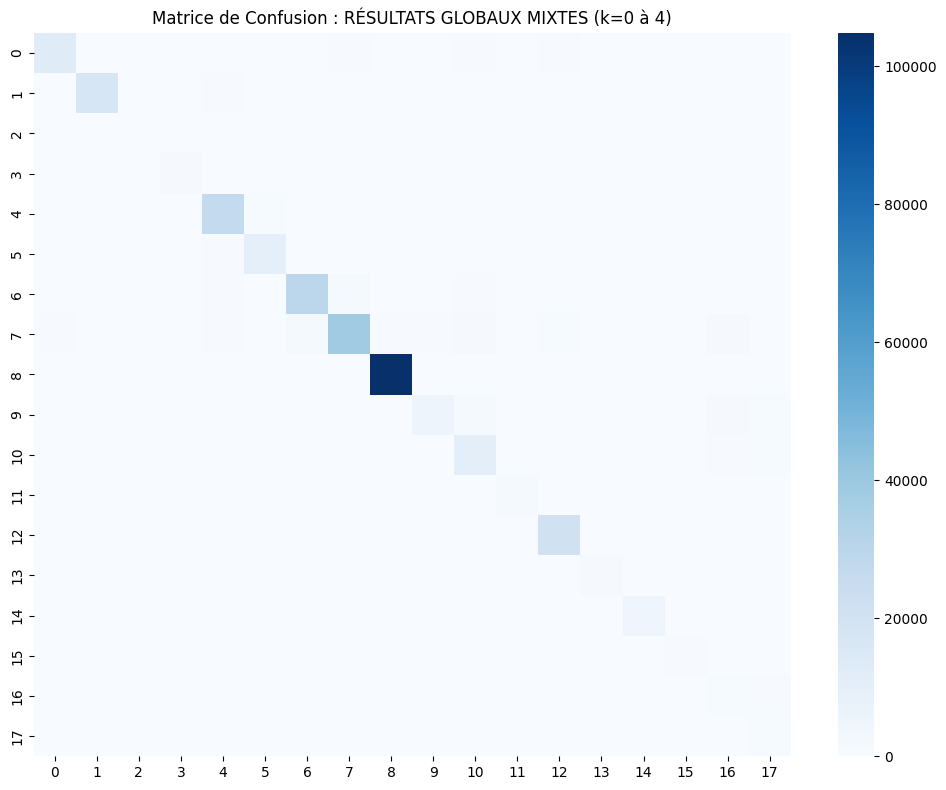

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, os, pickle
import pandas as pd
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. CONFIGURATION
# ==========================================
appareil = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Appareil utilisé : {appareil}")

chemin_base   = "/content/drive/MyDrive/PFE/results/preprocessed/csv"
chemin_modele = "/content/drive/MyDrive/PFE/results/models/cnn_bilstm_transformer_greedy_csv/phase_d2_model.pt"
fichier_sensi = "/content/drive/MyDrive/PFE/results/models/cnn_bilstm_transformer_greedy_csv/sensitivity_results.csv"

# ==========================================
# 1. CHARGEMENT DES DONNÉES
# ==========================================
print("\n📂 Chargement des fichiers .npy ...")
donnees_eval_X = np.load(os.path.join(chemin_base, "X_test.npy")).astype(np.float32)
donnees_eval_y = np.load(os.path.join(chemin_base, "y_test.npy")).astype(np.int64)
print(f"✅ X_test={donnees_eval_X.shape}, y_test={donnees_eval_y.shape}")

noms_features = []
chemin_meta = os.path.join(chemin_base, "csv_metadata.pkl")
if os.path.exists(chemin_meta):
    with open(chemin_meta, 'rb') as f:
        metadata = pickle.load(f)
    noms_features = metadata.get('features', metadata.get('feature_names', []))
    print(f"✅ {len(noms_features)} features chargées")

# ==========================================
# 2. FONCTIONS ORIGINALES DU PROJET
# ==========================================

def load_sensitivity_results(csv_path, feature_names):
    df = pd.read_csv(csv_path).sort_values('drop', ascending=False)
    idx = {name: i for i, name in enumerate(feature_names)}
    result = []
    for _, row in df.iterrows():
        feat = row['feature']
        if feat in idx:
            result.append((idx[feat], row['strategy'], float(row['drop'])))
    print(f"  -> {len(result)} (feature, strategy) pairs loaded from sensitivity analysis")
    print(f"  Top 5 most vulnerable:")
    for i, (fi, st, dr) in enumerate(result[:5], 1):
        fname = feature_names[fi] if fi < len(feature_names) else f"f{fi}"
        print(f"     {i}. {fname:<25} | {st:<14} | drop={dr*100:.1f}%")
    return result


class GreedyAttackSimulator:
    def __init__(self, sensitivity_results, feature_stats, feature_names=None,
                 n_continuous=None, verbose=True):
        self.results       = sensitivity_results
        self.stats         = feature_stats
        self.feature_names = feature_names or []
        self.n_continuous  = n_continuous

        self.feature_pool    = {}
        self.feature_weights = {}
        epsilon = 0.05

        for fi, st, drop in sensitivity_results:
            if fi not in self.feature_pool:
                self.feature_pool[fi]    = []
                self.feature_weights[fi] = max(0.0, drop) + epsilon
            self.feature_pool[fi].append(st)

        self.available_features = list(self.feature_pool.keys())
        if len(self.available_features) > 0:
            weights = np.array([self.feature_weights[f] for f in self.available_features])
            self.sampling_probs = weights / weights.sum() if weights.sum() > 0 else np.ones(len(weights)) / len(weights)
        else:
            self.sampling_probs = np.array([])

        self._build_constraints()

        if verbose:
            print(f"  [Simulator] {len(self.available_features)} distinct features in vulnerability dictionary.")

    def _build_constraints(self):
        fnames = self.feature_names
        has_pkt_dir = any(f.startswith('pkt_dir_') for f in fnames)
        if has_pkt_dir:
            self.dependent_pairs = {
                'reversePacketTotalCount': 'packetTotalCount',
                'reverseOctetTotalCount':  'octetTotalCount',
                'reverseAverageInterarrivalTime': 'averageInterarrivalTime',
            }
        else:
            self.dependent_pairs = {
                'inPacketCount':    'outPacketCount',
                'inByteCount':      'outByteCount',
                'inAvgIAT':         'outAvgIAT',
                'inAvgPacketSize':  'outAvgPacketSize',
            }
        self.dependent_indices = []
        for dep_name, indep_name in self.dependent_pairs.items():
            if dep_name in fnames and indep_name in fnames:
                self.dependent_indices.append(
                    (fnames.index(indep_name), fnames.index(dep_name))
                )

    def projection(self, X):
        X_proj = X.copy()
        n_cont = self.n_continuous
        if n_cont is not None:
            if X_proj.ndim == 3:
                X_proj[:, :, :n_cont] = np.clip(X_proj[:, :, :n_cont], -3.0, 3.0)
                X_proj[:, :, n_cont:] = np.clip(np.round(X_proj[:, :, n_cont:]), 0, 1)
            elif X_proj.ndim == 2:
                X_proj[:, :n_cont] = np.clip(X_proj[:, :n_cont], -3.0, 3.0)
                X_proj[:, n_cont:] = np.clip(np.round(X_proj[:, n_cont:]), 0, 1)
        else:
            X_proj = np.clip(X_proj, -3.0, 3.0)

        for indep_idx, dep_idx in self.dependent_indices:
            if n_cont is not None and (dep_idx >= n_cont or indep_idx >= n_cont):
                continue
            if X_proj.ndim == 3:
                ratio = np.abs(X_proj[:, :, dep_idx]) / (np.abs(X_proj[:, :, indep_idx]) + 1e-8)
                X_proj[:, :, dep_idx] = X_proj[:, :, indep_idx] * np.clip(ratio, 0.5, 2.0)
            elif X_proj.ndim == 2:
                ratio = np.abs(X_proj[:, dep_idx]) / (np.abs(X_proj[:, indep_idx]) + 1e-8)
                X_proj[:, dep_idx] = X_proj[:, indep_idx] * np.clip(ratio, 0.5, 2.0)
        return X_proj

    def apply_strategy(self, X, feat_idx, strategy):
        X = X.copy()
        if strategy == 'Zero':
            X[:, :, feat_idx] = 0.0
        elif strategy == 'Mimic_Mean':
            X[:, :, feat_idx] = self.stats[feat_idx]['mean']
        elif strategy == 'Mimic_95th':
            X[:, :, feat_idx] = self.stats[feat_idx]['p95']
        elif strategy == 'Padding_x10':
            X[:, :, feat_idx] = np.clip(X[:, :, feat_idx] * 10.0, -5.0, 5.0)
        return X

    def generate_greedy(self, X, k):
        """Sélection aléatoire pondérée de k features — méthode originale."""
        X_adv  = X.copy()
        n_avail = len(self.available_features)
        if n_avail == 0:
            return X_adv
        k_actual = min(k, n_avail)
        chosen   = np.random.choice(self.available_features, size=k_actual,
                                    replace=False, p=self.sampling_probs)
        for feat_idx in chosen:
            strategy = np.random.choice(self.feature_pool[feat_idx])
            X_adv    = self.apply_strategy(X_adv, feat_idx, strategy)
        return self.projection(X_adv)

    @classmethod
    def compute_feature_stats(cls, X_train):
        X_flat = X_train.reshape(-1, X_train.shape[-1])
        stats  = {}
        for i in range(X_flat.shape[1]):
            col = X_flat[:, i]
            stats[i] = {
                'mean': float(col.mean()),
                'p95':  float(np.percentile(col, 95)),
                'std':  float(col.std()),
            }
        return stats

# ==========================================
# 3. ARCHITECTURE EXACTE DU MODÈLE
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model=128, max_len=60, dropout=0.2):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(1, max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[0, :, 0::2] = torch.sin(pos * div)
        pe[0, :, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


class CNNBiLSTMTransformer(nn.Module):
    def __init__(self, n_features=16, n_classes=18):
        super().__init__()
        self.cnn_branch1 = nn.Sequential(
            nn.Conv1d(n_features, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=1, padding=1),
            nn.BatchNorm1d(32)
        )
        self.cnn_branch2 = nn.Sequential(
            nn.Conv1d(n_features, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=1, padding=1),
            nn.BatchNorm1d(32)
        )
        self.bilstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=2,
                               batch_first=True, bidirectional=True, dropout=0.3)
        self.pos_enc    = PositionalEncoding(d_model=128, max_len=60, dropout=0.2)
        self.layer_norm = nn.LayerNorm(128)
        encoder_layer   = nn.TransformerEncoderLayer(d_model=128, nhead=4,
                                                      dim_feedforward=512, dropout=0.2,
                                                      activation='gelu', batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.classifier  = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x_t = x.permute(0, 2, 1)
        b1  = self.cnn_branch1(x_t).permute(0, 2, 1)
        b2  = self.cnn_branch2(x_t).permute(0, 2, 1)
        min_len = min(b1.size(1), b2.size(1))
        x = torch.cat([b1[:, :min_len, :], b2[:, :min_len, :]], dim=2)
        x, _ = self.bilstm(x)
        x = self.pos_enc(x)
        x = self.layer_norm(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)

# ==========================================
# 4. CHARGEMENT DES POIDS
# ==========================================
print(f"\n📂 Chargement du checkpoint...")
checkpoint = torch.load(chemin_modele, map_location=appareil)
model = CNNBiLSTMTransformer(n_features=16, n_classes=18).to(appareil)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✅ Modèle chargé ! Paramètres : {sum(p.numel() for p in model.parameters()):,}")

# ==========================================
# 5. SIMULATEUR D'ATTAQUES
# ==========================================
print("\n🔧 Chargement du simulateur d'attaques...")
sensibilite    = load_sensitivity_results(fichier_sensi, noms_features)
stats_features = GreedyAttackSimulator.compute_feature_stats(donnees_eval_X)
simulateur     = GreedyAttackSimulator(sensibilite, stats_features,
                                       feature_names=noms_features, n_continuous=16)
print("✅ Simulateur prêt.")

# ==========================================
# 6. FONCTIONS D'ÉVALUATION
# ==========================================
taille_lot = 1024

def faire_predictions(donnees):
    liste_preds = []
    with torch.no_grad():
        for i in range(0, len(donnees), taille_lot):
            fin   = min(i + taille_lot, len(donnees))
            lot_x = torch.FloatTensor(donnees[i:fin]).to(appareil)
            preds = model(lot_x).argmax(dim=1).cpu().numpy()
            liste_preds.extend(preds)
    return np.array(liste_preds)


def afficher_metriques(y_vrai, y_predi, titre):
    print(f"\n{'='*55}\n{titre}\n{'='*55}")
    print(classification_report(y_vrai, y_predi))
    matrice = confusion_matrix(y_vrai, y_predi)
    fp = matrice.sum(axis=0) - np.diag(matrice)
    fn = matrice.sum(axis=1) - np.diag(matrice)
    tp = np.diag(matrice)
    tn = matrice.sum() - (fp + fn + tp)
    print("\n--- Analyse d'Erreurs ---")
    print(f"Total FP  : {fp.sum():,}")
    print(f"Total FN  : {fn.sum():,}")
    print(f"FPR moyen : {(fp/(fp+tn+1e-9)).mean():.4f}")
    print(f"FNR moyen : {(fn/(fn+tp+1e-9)).mean():.4f}")
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrice, annot=False, cmap='Blues')
    plt.title(f"Matrice de Confusion : {titre}")
    plt.tight_layout()
    plt.show()

# ==========================================
# 7. DATASET MIXTE (k=0 à 4)
# ==========================================
print("\n🔀 Construction du dataset mixte (k=0 à 4)...")
g   = np.random.RandomState(42)
idx = g.permutation(len(donnees_eval_X))
sz  = len(donnees_eval_X) // 5

blocs_x, blocs_y, etiquettes_k = [], [], []

for niv in range(5):
    debut = niv * sz
    fin   = (niv + 1) * sz if niv < 4 else len(donnees_eval_X)
    x_niv = donnees_eval_X[idx[debut:fin]]
    y_niv = donnees_eval_y[idx[debut:fin]]

    if niv == 0:
        print(f"  ➤ k=0 (Clean)      : {len(x_niv):,} samples")
        blocs_x.append(x_niv)
    else:
        print(f"  ➤ Génération k={niv} : {len(x_niv):,} samples...")
        # Appel à generate_greedy par batch pour éviter OOM
        x_adv = np.zeros_like(x_niv)
        for i in range(0, len(x_niv), taille_lot):
            fin_b = min(i + taille_lot, len(x_niv))
            x_adv[i:fin_b] = simulateur.generate_greedy(x_niv[i:fin_b], k=niv)
        blocs_x.append(x_adv)

    blocs_y.append(y_niv)
    etiquettes_k.extend([niv] * len(y_niv))

x_final            = np.concatenate(blocs_x, axis=0)
y_final            = np.concatenate(blocs_y, axis=0)
etiquettes_finales = np.array(etiquettes_k)
print(f"\n✅ Dataset mixte : {x_final.shape[0]:,} samples au total")

# ==========================================
# 8. ÉVALUATION FINALE
# ==========================================
print("\n🔍 Prédiction en cours...")
predictions_finales = faire_predictions(x_final)

print(f"\n{'='*55}")
print("ACCURACY DÉTAILLÉE PAR K")
print(f"{'='*55}")
for niv in range(5):
    masque = (etiquettes_finales == niv)
    acc    = (predictions_finales[masque] == y_final[masque]).mean()
    label  = "Clean      " if niv == 0 else "Adversarial"
    print(f"  k={niv} ({label}) → Accuracy : {acc:.4f}  ({masque.sum():,} samples)")

afficher_metriques(y_final, predictions_finales, "RÉSULTATS GLOBAUX MIXTES (k=0 à 4)")



In [ ]:
# ==========================================
# 4. CHARGEMENT DES CHECKPOINTS
# ==========================================
dossier_epochs = "/content/drive/MyDrive/PFE/results/models/cnn_bilstm_transformer_greedy_csv/phase_d2_model_epochs"

fichiers_epochs = sorted([
    f for f in os.listdir(dossier_epochs)
    if f.endswith(".pt")
])

print(f"\n✅ {len(fichiers_epochs)} checkpoints trouvés")

# ==========================================
# 5. SIMULATEUR D'ATTAQUES
# ==========================================
print("\n🔧 Chargement du simulateur d'attaques...")
sensibilite    = load_sensitivity_results(fichier_sensi, noms_features)
stats_features = GreedyAttackSimulator.compute_feature_stats(donnees_eval_X)

simulateur = GreedyAttackSimulator(
    sensibilite,
    stats_features,
    feature_names=noms_features,
    n_continuous=16
)

print("✅ Simulateur prêt.")

# ==========================================
# 6. FONCTIONS D'ÉVALUATION
# ==========================================
taille_lot = 1024

def faire_predictions(donnees):
    liste_preds = []

    with torch.no_grad():
        for i in range(0, len(donnees), taille_lot):

            fin = min(i + taille_lot, len(donnees))

            lot_x = torch.FloatTensor(donnees[i:fin]).to(appareil)

            preds = model(lot_x).argmax(dim=1).cpu().numpy()

            liste_preds.extend(preds)

    return np.array(liste_preds)


def afficher_metriques(y_vrai, y_predi, titre):

    print(f"\n{'='*55}")
    print(titre)
    print(f"{'='*55}")

    print(classification_report(y_vrai, y_predi))

    matrice = confusion_matrix(y_vrai, y_predi)

    fp = matrice.sum(axis=0) - np.diag(matrice)
    fn = matrice.sum(axis=1) - np.diag(matrice)
    tp = np.diag(matrice)
    tn = matrice.sum() - (fp + fn + tp)

    print("\n--- Analyse d'Erreurs ---")
    print(f"Total FP  : {fp.sum():,}")
    print(f"Total FN  : {fn.sum():,}")
    print(f"FPR moyen : {(fp/(fp+tn+1e-9)).mean():.4f}")
    print(f"FNR moyen : {(fn/(fn+tp+1e-9)).mean():.4f}")

    plt.figure(figsize=(10, 8))

    sns.heatmap(matrice, annot=False, cmap='Blues')

    plt.title(f"Matrice de Confusion : {titre}")

    plt.tight_layout()
    plt.show()

# ==========================================
# 7. DATASET MIXTE (k=0 à 4)
# ==========================================
print("\n🔀 Construction du dataset mixte (k=0 à 4)...")

g = np.random.RandomState(42)

idx = g.permutation(len(donnees_eval_X))

sz = len(donnees_eval_X) // 5

blocs_x = []
blocs_y = []
etiquettes_k = []

for niv in range(5):

    debut = niv * sz
    fin   = (niv + 1) * sz if niv < 4 else len(donnees_eval_X)

    x_niv = donnees_eval_X[idx[debut:fin]]
    y_niv = donnees_eval_y[idx[debut:fin]]

    if niv == 0:

        print(f"  ➤ k=0 (Clean)      : {len(x_niv):,} samples")

        blocs_x.append(x_niv)

    else:

        print(f"  ➤ Génération k={niv} : {len(x_niv):,} samples...")

        x_adv = np.zeros_like(x_niv)

        for i in range(0, len(x_niv), taille_lot):

            fin_b = min(i + taille_lot, len(x_niv))

            x_adv[i:fin_b] = simulateur.generate_greedy(
                x_niv[i:fin_b],
                k=niv
            )

        blocs_x.append(x_adv)

    blocs_y.append(y_niv)

    etiquettes_k.extend([niv] * len(y_niv))

x_final = np.concatenate(blocs_x, axis=0)

y_final = np.concatenate(blocs_y, axis=0)

etiquettes_finales = np.array(etiquettes_k)

print(f"\n✅ Dataset mixte : {x_final.shape[0]:,} samples au total")

# ==========================================
# 8. BOUCLE SUR TOUS LES EPOCHS
# ==========================================
resultats = []

for fichier_epoch in fichiers_epochs:

    chemin_checkpoint = os.path.join(dossier_epochs, fichier_epoch)

    print(f"\n{'#'*70}")
    print(f"📂 Évaluation : {fichier_epoch}")
    print(f"{'#'*70}")

    # -----------------------------
    # Chargement modèle
    # -----------------------------
    checkpoint = torch.load(
        chemin_checkpoint,
        map_location=appareil
    )

    model = CNNBiLSTMTransformer(
        n_features=16,
        n_classes=18
    ).to(appareil)

    model.load_state_dict(checkpoint['model_state_dict'])

    model.eval()

    # -----------------------------
    # Prédictions
    # -----------------------------
    print("\n🔍 Prédiction en cours...")

    predictions_finales = faire_predictions(x_final)

    # -----------------------------
    # Accuracy globale
    # -----------------------------
    acc_globale = (predictions_finales == y_final).mean()

    print(f"\nAccuracy Globale : {acc_globale:.4f}")

    # -----------------------------
    # Accuracy par k
    # -----------------------------
    accs_k = {}

    print(f"\n{'='*55}")
    print("ACCURACY DÉTAILLÉE PAR K")
    print(f"{'='*55}")

    for niv in range(5):

        masque = (etiquettes_finales == niv)

        acc = (
            predictions_finales[masque]
            == y_final[masque]
        ).mean()

        accs_k[niv] = acc

        label = "Clean      " if niv == 0 else "Adversarial"

        print(
            f"  k={niv} ({label}) "
            f"→ Accuracy : {acc:.4f}  "
            f"({masque.sum():,} samples)"
        )

    resultats.append({
        'checkpoint': fichier_epoch,
        'acc_global': acc_globale,
        'acc_k0': accs_k[0],
        'acc_k1': accs_k[1],
        'acc_k2': accs_k[2],
        'acc_k3': accs_k[3],
        'acc_k4': accs_k[4],
    })

# ==========================================
# 9. TABLEAU FINAL
# ==========================================
df_resultats = pd.DataFrame(resultats)

print(f"\n{'#'*70}")
print("📊 RÉSULTATS FINAUX")
print(f"{'#'*70}")

display(df_resultats.sort_values('acc_global', ascending=False))



✅ 20 checkpoints trouvés

🔧 Chargement du simulateur d'attaques...
  -> 60 (feature, strategy) pairs loaded from sensitivity analysis
  Top 5 most vulnerable:
     1. outMaxPktSize             | Mimic_95th     | drop=83.5%
     2. outAvgPacketSize          | Padding_x10    | drop=83.0%
     3. outAvgPacketSize          | Mimic_95th     | drop=81.5%
     4. outMaxPktSize             | Padding_x10    | drop=80.9%
     5. inMaxPktSize              | Padding_x10    | drop=80.6%
  [Simulator] 15 distinct features in vulnerability dictionary.
✅ Simulateur prêt.

🔀 Construction du dataset mixte (k=0 à 4)...
  ➤ k=0 (Clean)      : 63,962 samples
  ➤ Génération k=1 : 63,962 samples...
  ➤ Génération k=2 : 63,962 samples...
  ➤ Génération k=3 : 63,962 samples...
  ➤ Génération k=4 : 63,963 samples...

✅ Dataset mixte : 319,811 samples au total

######################################################################
📂 Évaluation : epoch_1.pt
#######################################################

,checkpoint,acc_global,acc_k0,acc_k1,acc_k2,acc_k3,acc_k4
5,epoch_14.pt,0.914418,0.936681,0.941590,0.924314,0.892858,0.876647
17,epoch_7.pt,0.913480,0.934758,0.940308,0.924064,0.893171,0.875100
15,epoch_5.pt,0.913099,0.939339,0.939292,0.921891,0.890748,0.874224
0,epoch_1.pt,0.912783,0.934868,0.937729,0.921500,0.893421,0.876397
7,epoch_16.pt,0.912417,0.936259,0.940996,0.922376,0.890451,0.872004
12,epoch_20.pt,0.912373,0.942497,0.937635,0.921500,0.889403,0.870832
19,epoch_9.pt,0.911989,0.934680,0.939964,0.922579,0.890263,0.872458
11,epoch_2.pt,0.911789,0.933945,0.938604,0.921063,0.890513,0.874818
8,epoch_17.pt,0.911216,0.925956,0.941465,0.923361,0.890826,0.874474
3,epoch_12.pt,0.911132,0.940746,0.936494,0.919952,0.888059,0.870409


In [ ]:
# ─── MODEL: NLP-CNN-BiLSTM-Transformer on CSV (Greedy Adversarial) ────────────────────────
MODEL = 'nlp_cnn_bilstm_transformer'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — NLP-CNN-BILSTM-TRANSFORMER on CSV')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_csv')

if DATASETS in ['csv', 'both']:
    data = load_dataset_from_drive('csv')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='csv',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_csv')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load CSV data')
else:
    print('Skipping CSV dataset')

print(f'\n NLP-CNN-BILSTM-TRANSFORMER on CSV DONE')


In [ ]:
# ─── MODEL: NLP-Transformer on CSV (Greedy Adversarial) ────────────────────────
MODEL = 'nlp_transformer'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — NLP-TRANSFORMER on CSV')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_csv')

if DATASETS in ['csv', 'both']:
    data = load_dataset_from_drive('csv')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='csv',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_csv')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load CSV data')
else:
    print('Skipping CSV dataset')

print(f'\n NLP-TRANSFORMER on CSV DONE')


# RAM Cleanup Before JSON Phase

In [ ]:
# ─── CLEANUP RAM BEFORE JSON PHASE ──────────────────────────────────────
print('\n' + '='*80)
print('  CLEANING RAM BEFORE JSON PHASE...')
print('='*80 + '\n')

aggressive_cleanup()
print('\n RAM cleaned. Ready for JSON phase.')


# Phase 5 : Greedy Adversarial Training on JSON

In [ ]:
def load_and_display_json_dataset(json_data_dir, seq_length=10, stride=10, max_records=None, save_dir=None):
    """Charge COMPLÈTEMENT le dataset JSON, affiche les infos, et sauvegarde sur Drive."""
    import sys
    import gc
    import numpy as np
    import pickle

    sys.path.insert(0, '/content/pfe')

    print("\n" + "=" * 70)
    print("  CHARGEMENT COMPLET DU DATASET JSON")
    print("=" * 70)

    print(f"\n  Répertoire : {json_data_dir}")
    print(f"  Seq length : {seq_length} | Stride : {stride}")
    print(f"  Max records: {max_records if max_records else 'Tous'}")

    json_files = sorted(glob.glob(f'{json_data_dir}/**/*.json', recursive=True))
    print(f"\n  Fichiers JSON trouvés : {len(json_files)}")

    for f in json_files:
        size_gb = os.path.getsize(f) / (1024**3)
        print(f"    {os.path.basename(f):<30s} : {size_gb:>10.2f} GB")

    total_gb = sum(os.path.getsize(f) for f in json_files) / (1024**3)
    print(f"\n  Taille totale : {total_gb:.2f} GB")

    # Charger le dataset complet via le vrai pipeline JSON
    print("\n  Chargement via le pipeline JSON (JsonIoTDataProcessor)...")
    from src.data.json_preprocessor import JsonIoTDataProcessor

    processor = JsonIoTDataProcessor()
    result = processor.process_all(
        data_dir=json_data_dir,
        seq_length=seq_length,
        stride=stride,
        max_records=max_records,
    )

    X_train, X_val, X_test, y_train, y_val, y_test, features, scaler, label_encoder = result
    n_continuous = 36  # JSON pipeline features

    print(f"\n  {'='*70}")
    print(f"  RÉSULTAT DU CHARGEMENT")
    print(f"  {'='*70}")
    print(f"    Features ({len(features)}) : {features[:5]}...")
    print(f"    Classes ({len(label_encoder.classes_)}) : {list(label_encoder.classes_)}")
    print(f"\n  Shapes des séquences (seq_length={seq_length}, stride={stride}) :")
    print(f"    Train : {X_train.shape}  →  {len(X_train):,} séquences")
    print(f"    Val   : {X_val.shape}  →  {len(X_val):,} séquences")
    print(f"    Test  : {X_test.shape}  →  {len(X_test):,} séquences")
    print(f"    Total : {len(X_train) + len(X_val) + len(X_test):,} séquences")

    print(f"\n  Distribution des classes (train) :")
    for cls in label_encoder.classes_:
        cls_id = label_encoder.transform([cls])[0]
        count = int(np.sum(y_train == cls_id))
        bar = '█' * max(1, count // 50)
        print(f"    {cls:<30s} : {count:>6,}  {bar}")

    # ─── Sauvegarder sur Drive ────────────────────────────────────────────
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        print(f"\n  💾 Sauvegarde du dataset JSON pré-traité sur Drive...")
        print(f"     Répertoire : {save_dir}")

        np.save(f'{save_dir}/X_train.npy', X_train)
        np.save(f'{save_dir}/X_val.npy', X_val)
        np.save(f'{save_dir}/X_test.npy', X_test)
        np.save(f'{save_dir}/y_train.npy', y_train)
        np.save(f'{save_dir}/y_val.npy', y_val)
        np.save(f'{save_dir}/y_test.npy', y_test)

        with open(f'{save_dir}/json_metadata.pkl', 'wb') as f:
            pickle.dump({
                'features': features,
                'scaler': scaler,
                'label_encoder': label_encoder,
                'n_continuous': n_continuous,
                'seq_length': seq_length,
                'stride': stride,
            }, f)

        # Marker file to indicate preprocessing is complete
        with open(f'{save_dir}/json_ready', 'w') as f:
            f.write('ready')

        saved_gb = (X_train.nbytes + X_val.nbytes + X_test.nbytes +
                    y_train.nbytes + y_val.nbytes + y_test.nbytes) / (1024**3)
        print(f"  ✅ Dataset JSON sauvegardé ({saved_gb:.2f} GB)")
        print(f"     Fichiers : X_train, X_val, X_test, y_train, y_val, y_test, json_metadata.pkl")

    print(f"\n  {'='*70}")
    print(f"  ✅ Dataset JSON chargé complètement en RAM")
    print(f"  {'='*70}\n")

    return {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'features': features, 'scaler': scaler,
        'label_encoder': label_encoder, 'n_continuous': n_continuous
    }

# ─── JSON preprocessing directory on Drive ─────────────────────────────
JSON_PREPROCESSED_DIR = f'{DRIVE_RESULTS_DIR}/preprocessed/json'

if DATASETS in ['json', 'both']:
    json_data = load_and_display_json_dataset(
        JSON_DATA_DIR, seq_length=SEQ_LENGTH, stride=STRIDE,
        max_records=MAX_RECORDS, save_dir=JSON_PREPROCESSED_DIR
    )
else:
    json_data = None
    print('Skipping JSON dataset loading — DATASETS is not json or both')


In [ ]:
# ─── Cell: Load JSON Dataset ─────────────────────────────────────────────
import os
import pickle
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

if DATASETS in ['json', 'both']:
    JSON_BASE_DIR = f"{DRIVE_RESULTS_DIR}/preprocessed/json"
    JSON_BALANCED_DIR = f"{DRIVE_RESULTS_DIR}/preprocessed/json_smote"
    JSON_DIR = JSON_BALANCED_DIR if os.path.exists(f"{JSON_BALANCED_DIR}/json_ready") else JSON_BASE_DIR

    print(f"Loading JSON dataset from: {JSON_DIR}")

    X_train = np.load(f"{JSON_DIR}/X_train.npy")
    X_val = np.load(f"{JSON_DIR}/X_val.npy")
    X_test = np.load(f"{JSON_DIR}/X_test.npy")
    y_train = np.load(f"{JSON_DIR}/y_train.npy")
    y_val = np.load(f"{JSON_DIR}/y_val.npy")
    y_test = np.load(f"{JSON_DIR}/y_test.npy")

    with open(f"{JSON_DIR}/json_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    print(f"  X_train : {X_train.shape} | y_train : {y_train.shape}")
    print(f"  X_val   : {X_val.shape}   | y_val   : {y_val.shape}")
    print(f"  X_test  : {X_test.shape}  | y_test  : {y_test.shape}")

    print("\nMetadata keys:", list(metadata.keys()))

    if 'class_names' in metadata:
        label_names = metadata['class_names']
    elif 'label_encoder' in metadata:
        label_names = metadata['label_encoder'].classes_
    elif 'classes' in metadata:
        label_names = metadata['classes']
    else:
        label_names = None
        print("  [!] Aucun label_names trouvé dans metadata — affichage class_0, class_1...")

    print(f"  Classes : {label_names}")

    print("=" * 70)
    print("  CLASS DISTRIBUTION ANALYSIS — JSON DATASET")
    print("=" * 70)

    splits = {
        'TRAIN': y_train,
        'VAL': y_val,
        'TEST': y_test,
    }

    for split_name, y in splits.items():
        counter = Counter(y)
        total = len(y)
        n_cls = len(counter)

        print(f"\n{'─'*70}")
        print(f"  {split_name} SET — {total:,} samples | {n_cls} classes")
        print(f"{'─'*70}")
        print(f"  {'ID':>4} | {'Label':<35} | {'Count':>8} | {'%':>6} | Bar")
        print(f"  {'─'*4}-+-{'─'*35}-+-{'─'*8}-+-{'─'*6}-+-{'─'*25}")

        for cls_id, count in sorted(counter.items()):
            pct = 100.0 * count / total
            name = (
                label_names[cls_id]
                if label_names is not None and cls_id < len(label_names)
                else f"class_{cls_id}"
            )
            bar = "█" * int(pct / 2)
            print(f"  {cls_id:>4} | {name:<35} | {count:>8,} | {pct:>5.1f}% | {bar}")

        counts = np.array([counter[c] for c in sorted(counter)])
        ratio = counts.max() / (counts.min() + 1e-9)
        entropy = -np.sum((counts / total) * np.log2(counts / total + 1e-12))
        balance = entropy / np.log2(n_cls)

        print(f"\n  ► Total samples      : {total:,}")
        print(f"  ► Min samples/class  : {counts.min():,}  → class {np.argmin(counts)}"
              + (f" ({label_names[np.argmin(counts)]})" if label_names is not None else ""))
        print(f"  ► Max samples/class  : {counts.max():,}  → class {np.argmax(counts)}"
              + (f" ({label_names[np.argmax(counts)]})" if label_names is not None else ""))
        print(f"  ► Imbalance ratio    : {ratio:.1f}x  "
              f"({'✅ OK' if ratio < 5 else '⚠️  Moderate' if ratio < 20 else '🔴 Severe'})")
        print(f"  ► Balance score      : {balance:.3f}  "
              f"({'✅ OK' if balance > 0.85 else '⚠️  Moderate' if balance > 0.70 else '🔴 Severe'})")

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle("Class Distribution per Split — JSON Dataset", fontsize=14, fontweight='bold')

    colors = ['steelblue', 'darkorange', 'seagreen']

    for ax, (split_name, y), color in zip(axes, splits.items(), colors):
        counter = Counter(y)
        classes = sorted(counter.keys())
        counts = [counter[c] for c in classes]
        x_labels = (
            [label_names[c] for c in classes]
            if label_names is not None
            else [f"cls_{c}" for c in classes]
        )

        bars = ax.bar(range(len(classes)), counts, color=color, alpha=0.8, edgecolor='white')
        ax.set_xticks(range(len(classes)))
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
        ax.set_title(f"{split_name}  ({len(y):,} samples)", fontweight='bold')
        ax.set_ylabel("Number of samples")
        ax.set_xlabel("Class")

        mean_count = np.mean(counts)
        ax.axhline(mean_count, color='red', linestyle='--', linewidth=1.2, label=f"Mean = {mean_count:,.0f}")
        ax.legend(fontsize=8)

        for bar, cnt in zip(bars, counts):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(counts) * 0.01,
                f"{cnt:,}",
                ha='center',
                va='bottom',
                fontsize=6,
                rotation=90,
            )

    plt.tight_layout()
    save_path = f"{JSON_DIR}/class_distribution_json.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n  [Saved] {save_path}")

    json_data = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'features': metadata.get('features'), 'scaler': metadata.get('scaler'),
        'label_encoder': metadata.get('label_encoder'), 'n_continuous': metadata.get('n_continuous')
    }
else:
    json_data = None
    print('Skipping JSON dataset')


In [ ]:
# ─── Cell: Verify JSON Dataset After SMOTE ─────────────────────────────────────
import os
import pickle
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

if DATASETS in ['json', 'both']:
    JSON_BASE_DIR    = f"{DRIVE_RESULTS_DIR}/preprocessed/json"
    JSON_BALANCED_DIR = f"{DRIVE_RESULTS_DIR}/preprocessed/json_smote"

    smote_available = os.path.exists(f"{JSON_BALANCED_DIR}/X_train.npy")

    # ── Load ORIGINAL (pre-SMOTE)
    y_train_orig = np.load(f"{JSON_BASE_DIR}/y_train.npy")
    y_val_orig   = np.load(f"{JSON_BASE_DIR}/y_val.npy")
    y_test_orig  = np.load(f"{JSON_BASE_DIR}/y_test.npy")

    # ── Load SMOTE-balanced
    if smote_available:
        X_train = np.load(f"{JSON_BALANCED_DIR}/X_train.npy")
        X_val   = np.load(f"{JSON_BALANCED_DIR}/X_val.npy")
        X_test  = np.load(f"{JSON_BALANCED_DIR}/X_test.npy")
        y_train = np.load(f"{JSON_BALANCED_DIR}/y_train.npy")
        y_val   = np.load(f"{JSON_BALANCED_DIR}/y_val.npy")
        y_test  = np.load(f"{JSON_BALANCED_DIR}/y_test.npy")

        with open(f"{JSON_BALANCED_DIR}/json_metadata.pkl", "rb") as f:
            metadata = pickle.load(f)

        JSON_DIR = JSON_BALANCED_DIR
        print(f"✅ SMOTE cache found — loading from: {JSON_BALANCED_DIR}")
    else:
        X_train, X_val, X_test = [None]*3
        y_train, y_val, y_test = y_train_orig, y_val_orig, y_test_orig
        with open(f"{JSON_BASE_DIR}/json_metadata.pkl", "rb") as f:
            metadata = pickle.load(f)
        JSON_DIR = JSON_BASE_DIR
        print("⚠️  No SMOTE cache found — showing original only.")

    # ── Label names
    if 'class_names' in metadata:
        label_names = metadata['class_names']
    elif 'label_encoder' in metadata:
        label_names = metadata['label_encoder'].classes_
    elif 'classes' in metadata:
        label_names = metadata['classes']
    else:
        label_names = None

    def balance_metrics(counter, total):
        counts = np.array([counter[c] for c in sorted(counter)])
        n_cls  = len(counts)
        ratio  = counts.max() / (counts.min() + 1e-9)
        entropy = -np.sum((counts / total) * np.log2(counts / total + 1e-12))
        balance = entropy / np.log2(n_cls)
        return ratio, balance, counts

    print("\n" + "=" * 75)
    print("  SMOTE VERIFICATION — TRAIN SPLIT (only train is resampled)")
    print("=" * 75)

    counter_orig = Counter(y_train_orig)
    counter_smote = Counter(y_train)
    all_classes = sorted(set(counter_orig) | set(counter_smote))
    total_orig  = len(y_train_orig)
    total_smote = len(y_train)

    print(f"\n  {'ID':>4} | {'Label':<30} | {'Before':>8} | {'After':>8} | {'Δ Added':>8} | {'% Before':>8} | {'% After':>8}")
    print(f"  {'─'*4}-+-{'─'*30}-+-{'─'*8}-+-{'─'*8}-+-{'─'*8}-+-{'─'*8}-+-{'─'*8}")

    for cls_id in all_classes:
        orig_n  = counter_orig.get(cls_id, 0)
        smote_n = counter_smote.get(cls_id, 0)
        delta   = smote_n - orig_n
        pct_o   = 100.0 * orig_n  / total_orig
        pct_s   = 100.0 * smote_n / total_smote
        name    = (label_names[cls_id] if label_names is not None and cls_id < len(label_names)
                   else f"class_{cls_id}")
        flag    = " ✚" if delta > 0 else ""
        print(f"  {cls_id:>4} | {name:<30} | {orig_n:>8,} | {smote_n:>8,} | {delta:>+8,} | {pct_o:>7.2f}% | {pct_s:>7.2f}%{flag}")

    ratio_o, bal_o, _ = balance_metrics(counter_orig,  total_orig)
    ratio_s, bal_s, _ = balance_metrics(counter_smote, total_smote)

    print(f"\n  ┌─────────────────────────────────────────────────────────┐")
    print(f"  │  Metric              │    Before SMOTE  │   After SMOTE  │")
    print(f"  ├─────────────────────────────────────────────────────────┤")
    print(f"  │  Total samples       │ {total_orig:>15,}  │ {total_smote:>13,}  │")
    print(f"  │  Imbalance ratio     │ {ratio_o:>15.1f}x │ {ratio_s:>13.1f}x │")
    print(f"  │  Balance score       │ {bal_o:>15.3f}  │ {bal_s:>13.3f}  │")
    print(f"  └─────────────────────────────────────────────────────────┘")

    imb_icon = lambda r: '✅ OK' if r < 5 else '⚠️  Moderate' if r < 20 else '🔴 Severe'
    bal_icon = lambda b: '✅ OK' if b > 0.85 else '⚠️  Moderate' if b > 0.70 else '🔴 Severe'
    print(f"\n  Imbalance  : {imb_icon(ratio_o)} → {imb_icon(ratio_s)}")
    print(f"  Balance    : {bal_icon(bal_o)} → {bal_icon(bal_s)}")

    fig = plt.figure(figsize=(24, 10))
    fig.suptitle("Class Distribution — Before vs After SMOTE (JSON)", fontsize=15, fontweight='bold')

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    plot_configs = [
        (0, 0, y_train_orig, f"TRAIN — Before SMOTE  ({total_orig:,})",  "steelblue"),
        (0, 1, y_train,      f"TRAIN — After SMOTE   ({total_smote:,})", "seagreen"),
        (1, 0, y_val_orig,   f"VAL   — Unchanged     ({len(y_val):,})",  "darkorange"),
        (1, 1, y_test_orig,  f"TEST  — Unchanged     ({len(y_test):,})", "tomato"),
    ]

    for row, col, y_data, title, color in plot_configs:
        ax = fig.add_subplot(gs[row, col])
        counter = Counter(y_data)
        classes = sorted(counter.keys())
        counts  = [counter[c] for c in classes]
        xlabels = (
            [label_names[c] for c in classes] if label_names is not None
            else [f"cls_{c}" for c in classes]
        )
        bars = ax.bar(range(len(classes)), counts, color=color, alpha=0.82, edgecolor='white')
        ax.set_xticks(range(len(classes)))
        ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=7)
        ax.set_title(title, fontweight='bold', fontsize=9)
        ax.set_ylabel("Samples")
        mean_c = np.mean(counts)
        ax.axhline(mean_c, color='black', linestyle='--', linewidth=1, label=f"Mean={mean_c:,.0f}")
        ax.legend(fontsize=7)
        for bar, cnt in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                    f"{cnt:,}", ha='center', va='bottom', fontsize=5.5, rotation=90)

    ax_delta = fig.add_subplot(gs[:, 2])
    deltas   = [counter_smote.get(c, 0) - counter_orig.get(c, 0) for c in all_classes]
    xlabels  = (
        [label_names[c] for c in all_classes] if label_names is not None
        else [f"cls_{c}" for c in all_classes]
    )
    bar_colors = ["seagreen" if d > 0 else "lightgray" for d in deltas]
    ax_delta.barh(range(len(all_classes)), deltas, color=bar_colors, edgecolor='white', alpha=0.85)
    ax_delta.set_yticks(range(len(all_classes)))
    ax_delta.set_yticklabels(xlabels, fontsize=8)
    ax_delta.set_xlabel("Synthetic samples added")
    ax_delta.set_title("Δ Synthetic Samples Added\n(SMOTE — train only)", fontweight='bold', fontsize=9)
    ax_delta.axvline(0, color='black', linewidth=0.8)
    for i, (d, cls_id) in enumerate(zip(deltas, all_classes)):
        if d > 0:
            ax_delta.text(d + max(deltas)*0.01, i, f"+{d:,}", va='center', fontsize=7)

    save_path = f"{JSON_DIR}/smote_verification_json.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n  [Saved] {save_path}")

    if smote_available:
        print("\n  Shapes after SMOTE:")
        print(f"    X_train : {X_train.shape} | y_train : {y_train.shape}")
        print(f"    X_val   : {X_val.shape}   | y_val   : {y_val.shape}")
        print(f"    X_test  : {X_test.shape}  | y_test  : {y_test.shape}")


In [ ]:
# ─── MODEL: LSTM on JSON (Greedy Adversarial) ────────────────────────
MODEL = 'lstm'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — LSTM on JSON')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_json')

if DATASETS in ['json', 'both']:
    data = load_dataset_from_drive('json')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='json',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_json')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load JSON data')
else:
    print('Skipping JSON dataset')

print(f'\n LSTM on JSON DONE')


In [ ]:
# ─── MODEL: BiLSTM on JSON (Greedy Adversarial) ────────────────────────
MODEL = 'bilstm'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — BILSTM on JSON')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_json')

if DATASETS in ['json', 'both']:
    data = load_dataset_from_drive('json')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='json',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_json')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load JSON data')
else:
    print('Skipping JSON dataset')

print(f'\n BILSTM on JSON DONE')


In [ ]:
# ─── MODEL: CNN-LSTM on JSON (Greedy Adversarial) ────────────────────────
MODEL = 'cnn_lstm'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — CNN-LSTM on JSON')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_json')

if DATASETS in ['json', 'both']:
    data = load_dataset_from_drive('json')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='json',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_json')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load JSON data')
else:
    print('Skipping JSON dataset')

print(f'\n CNN-LSTM on JSON DONE')


In [ ]:
# ─── MODEL: XGBoost-LSTM on JSON (Greedy Adversarial) ────────────────────────
MODEL = 'xgboost_lstm'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — XGBOOST-LSTM on JSON')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_json')

if DATASETS in ['json', 'both']:
    data = load_dataset_from_drive('json')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='json',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_json')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load JSON data')
else:
    print('Skipping JSON dataset')

print(f'\n XGBOOST-LSTM on JSON DONE')


In [ ]:
# ─── MODEL: Transformer on JSON (Greedy Adversarial) ────────────────────────
MODEL = 'transformer'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — TRANSFORMER on JSON')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_json')

if DATASETS in ['json', 'both']:
    data = load_dataset_from_drive('json')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='json',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_json')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load JSON data')
else:
    print('Skipping JSON dataset')

print(f'\n TRANSFORMER on JSON DONE')


In [ ]:
# ─── MODEL: CNN-BiLSTM-Transformer on JSON (Greedy Adversarial) ────────────────────────
MODEL = 'cnn_bilstm_transformer'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — CNN-BILSTM-TRANSFORMER on JSON')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_json')

if DATASETS in ['json', 'both']:
    data = load_dataset_from_drive('json')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='json',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_json')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load JSON data')
else:
    print('Skipping JSON dataset')

print(f'\n CNN-BILSTM-TRANSFORMER on JSON DONE')


In [ ]:
# ─── MODEL: NLP-CNN-BiLSTM-Transformer on JSON (Greedy Adversarial) ────────────────────────
MODEL = 'nlp_cnn_bilstm_transformer'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — NLP-CNN-BILSTM-TRANSFORMER on JSON')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_json')

if DATASETS in ['json', 'both']:
    data = load_dataset_from_drive('json')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='json',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_json')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load JSON data')
else:
    print('Skipping JSON dataset')

print(f'\n NLP-CNN-BILSTM-TRANSFORMER on JSON DONE')


In [ ]:
# ─── MODEL: NLP-Transformer on JSON (Greedy Adversarial) ────────────────────────
MODEL = 'nlp_transformer'
print(f'\n{"#"*80}')
print(f'  GREEDY ADVERSARIAL — NLP-TRANSFORMER on JSON')
print(f'{"#"*80}\n')

log_memory(f'before_{MODEL}_json')

if DATASETS in ['json', 'both']:
    data = load_dataset_from_drive('json')
    if data is not None:
        results = train_model_greedy(
            model_type=MODEL,
            dataset_type='json',
            data_dict=data,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        log_memory(f'after_{MODEL}_json')
        del data  # release numpy arrays from RAM
        try:
            del results
        except Exception:
            pass
        aggressive_cleanup()
    else:
        print('Failed to load JSON data')
else:
    print('Skipping JSON dataset')

print(f'\n NLP-TRANSFORMER on JSON DONE')


# Phase 6 : Results Visualization & Comparison

In [ ]:
# ─── Cell: Visualize Results ─────────────────────────────────────────────
import json
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path(DRIVE_RESULTS_DIR) / 'models'
if not results_dir.exists():
    print('No results found yet — run the training cells first.')
else:
    greedy_dirs = sorted([d for d in results_dir.iterdir() if d.is_dir() and 'greedy' in d.name])

    if not greedy_dirs:
        print('No greedy results found yet.')
    else:
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))

        for idx, dataset in enumerate(['csv', 'json']):
            ax = axes[idx]
            ds_dirs = [d for d in greedy_dirs if dataset in d.name]
            models = []
            clean_accs = []
            adv_k1 = []
            adv_k2 = []
            adv_k3 = []
            adv_k4 = []

            for d in sorted(ds_dirs):
                rf = d / 'greedy_results.json'
                if not rf.exists():
                    continue
                with open(rf) as f:
                    res = json.load(f)

                model_name = d.name.replace(f'_greedy_{dataset}', '').upper()
                models.append(model_name)
                clean_accs.append(res.get('clean_accuracy', 0))
                adv_k1.append(res.get('adversarial_accuracies', {}).get('k1', 0))
                adv_k2.append(res.get('adversarial_accuracies', {}).get('k2', 0))
                adv_k3.append(res.get('adversarial_accuracies', {}).get('k3', 0))
                adv_k4.append(res.get('adversarial_accuracies', {}).get('k4', 0))

            if not models:
                ax.set_title(f'{dataset.upper()} — No results yet')
                continue

            x = np.arange(len(models))
            width = 0.15

            ax.bar(x - 2*width, clean_accs, width, label='Clean', color='#2ecc71')
            ax.bar(x - width, adv_k1, width, label='Adv k=1', color='#3498db')
            ax.bar(x, adv_k2, width, label='Adv k=2', color='#e67e22')
            ax.bar(x + width, adv_k3, width, label='Adv k=3', color='#e74c3c')
            ax.bar(x + 2*width, adv_k4, width, label='Adv k=4', color='#9b59b6')

            ax.set_ylabel('Accuracy')
            ax.set_title(f'{dataset.upper()} — Greedy Adversarial Results')
            ax.set_xticks(x)
            ax.set_xticklabels(models, rotation=45, ha='right')
            ax.legend()
            ax.set_ylim(0, 1.05)
            ax.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        save_path = f'{DRIVE_RESULTS_DIR}/greedy_comparison.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Plot saved to {save_path}')

        # Phase progression plot per model
        for d in greedy_dirs:
            rf = d / 'greedy_results.json'
            if not rf.exists():
                continue
            with open(rf) as f:
                res = json.load(f)

            ct = res.get('crash_tests', {})
            if not ct:
                continue

            fig, ax = plt.subplots(figsize=(8, 5))
            phases = sorted(ct.keys())
            clean_vals = [ct[p].get('clean', 0) for p in phases]
            ax.plot(phases, clean_vals, 'o-', label='Clean', color='#2ecc71', linewidth=2)
            for k in [1, 2, 3, 4]:
                k_key = f'adv_k{k}'
                vals = [ct[p].get(k_key, None) for p in phases]
                if any(v is not None for v in vals):
                    vals = [v if v is not None else 0 for v in vals]
                    ax.plot(phases, vals, 'o--', label=f'Adv k={k}', alpha=0.7)

            ax.set_title(f"{d.name} — Accuracy by Phase")
            ax.set_xlabel('Phase')
            ax.set_ylabel('Accuracy')
            ax.legend()
            ax.grid(alpha=0.3)
            ax.set_ylim(0, 1.05)
            plt.tight_layout()
            plt.show()


In [ ]:
# ─── Cell: Comparative Summary Table ─────────────────────────────────────
import json
from pathlib import Path

results_dir = Path(DRIVE_RESULTS_DIR) / 'models'
if not results_dir.exists():
    print('No results found.')
else:
    greedy_dirs = sorted([d for d in results_dir.iterdir() if d.is_dir() and 'greedy' in d.name])

    print(f"{'Model + Dataset':<40} {'Clean':>8} {'k=1':>8} {'k=2':>8} {'k=3':>8} {'k=4':>8}")
    print('-' * 80)

    for d in greedy_dirs:
        rf = d / 'greedy_results.json'
        if not rf.exists():
            continue
        with open(rf) as f:
            res = json.load(f)

        name = d.name
        clean = res.get('clean_accuracy', 0)
        adv = res.get('adversarial_accuracies', {})
        k1 = adv.get('k1', 0)
        k2 = adv.get('k2', 0)
        k3 = adv.get('k3', 0)
        k4 = adv.get('k4', 0)

        print(f"{name:<40} {clean:>8.4f} {k1:>8.4f} {k2:>8.4f} {k3:>8.4f} {k4:>8.4f}")

    print('-' * 80)

    # Crash test summary
    print(f"\n{'Model + Dataset':<40} {'Phase':>8} {'Clean':>8} {'k=1':>8} {'k=2':>8} {'k=3':>8} {'k=4':>8}")
    print('-' * 100)
    for d in greedy_dirs:
        rf = d / 'greedy_results.json'
        if not rf.exists():
            continue
        with open(rf) as f:
            res = json.load(f)

        name = d.name
        ct = res.get('crash_tests', {})
        for phase_key in sorted(ct.keys()):
            phase_data = ct[phase_key]
            clean = phase_data.get('clean', 0)
            k1 = phase_data.get('adv_k1', 0)
            k2 = phase_data.get('adv_k2', 0)
            k3 = phase_data.get('adv_k3', 0)
            k4 = phase_data.get('adv_k4', 0)
            print(f"{name:<40} {phase_key:>8} {clean:>8.4f} {k1:>8.4f} {k2:>8.4f} {k3:>8.4f} {k4:>8.4f}")
    print('-' * 100)
    print('\n Comparison complete.')


In [ ]:
# ─── Git Push ──────────────────────────────────────────────────────────────
import subprocess

print('Pushing to GitHub...')
result = subprocess.run(['git', 'add', '-A'], capture_output=True, text=True, cwd='/content/pfe')
print(f'  git add: {result.returncode}')

result = subprocess.run(['git', 'commit', '-m', 'Update greedy adversarial training results'], capture_output=True, text=True, cwd='/content/pfe')
if result.returncode == 0:
    print(f'  git commit: OK')
else:
    print(f'  git commit: {result.stdout.strip()} {result.stderr.strip()}')

result = subprocess.run(['git', 'push'], capture_output=True, text=True, cwd='/content/pfe')
if result.returncode == 0:
    print('  Push successful!')
else:
    print(f'  git push stderr: {result.stderr.strip()[:500]}')
